# Resilient EV Charging Under Disruption

## Technical report notebook for DTU 42578 Advanced Business Analytics

This notebook is the final technical report for the project on resilience in EV charging operations. It is written as a structured report rather than an exploration log. The central question is whether mobile charging stations can be used intelligently to reduce queueing pressure when demand is uneven and charging infrastructure is disrupted.

The intended research question is:

**Can a reinforcement learning policy improve resilience in an EV charging corridor by dynamically reallocating mobile charging stations to reduce queue length and waiting time under disruptions?**

A crucial caveat shapes the report: the current checkout contains the active simulator, the active configs, copied RL training history, and baseline rollout artifacts, but it does **not** contain a current-compatible RL checkpoint or RL rollout artifact for the active 27-feature, 5-action A-B-C benchmark. The report therefore separates three things carefully:

- the **RL formulation**, which can be described precisely,
- the **RL training diagnostics**, which are available from copied training history,
- the **reproducible operational rollout evidence**, which is currently available for the fixed baseline and the currently copied RL agent artifact.

The notebook follows this exact structure:

1. <a href="#motivation-problem-definition">Motivation / problem definition</a>  

2. <a href="#simulation-environment">Simulation environment</a>  

3. <a href="#simulation-design">Simulation design</a>  

4. <a href="#rl-agent-and-methods">RL agent and methods</a>  

5. <a href="#reward-calibration">Reward calibration</a>  

6. <a href="#training-setup">Training setup</a>  

7. <a href="#training-the-model">Training the model</a>  

8. <a href="#simulation-comparison-rollout">Simulation comparison rollout</a>  

9. <a href="#summary-metrics-table">Summary metrics table</a>  

10. <a href="#spatial-awareness">Spatial awareness</a>  

11. <a href="#limitations">Limitations</a>  

12. <a href="#conclusion">Conclusion</a>  

13. <a href="#appendix">Appendix</a>


In [176]:

from pathlib import Path
import sys
import copy
import importlib

REPO_ROOT = next(
    path.parent if path.name == 'exam_submission' else path
    for path in [Path.cwd(), *Path.cwd().parents]
    if path.name == 'exam_submission' or (path / 'exam_submission').exists()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SUBMISSION_SRC = REPO_ROOT / 'exam_submission' / 'src'
if str(SUBMISSION_SRC) not in sys.path:
    sys.path.insert(0, str(SUBMISSION_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import exam_submission.utils.demo_runner as demo_runner_module
import exam_submission.utils.load_artifacts as load_artifacts_module
import exam_submission.utils.plotting as plotting_module
import exam_submission.utils.project_summary as project_summary_module

demo_runner_module = importlib.reload(demo_runner_module)
load_artifacts_module = importlib.reload(load_artifacts_module)
plotting_module = importlib.reload(plotting_module)
project_summary_module = importlib.reload(project_summary_module)

from exam_submission.utils.demo_runner import run_appendix_demo
from exam_submission.utils.load_artifacts import (
    load_core_configs,
    load_generated_reward_sweeps,
    load_heldout_runs,
    load_reward_sweep_summary,
    load_training_history,
)
from exam_submission.utils.plotting import (
    set_report_style,
    plot_corridor_schematic,
    plot_demand_profile,
    plot_disruption_scenario,
    plot_training_history,
)
from exam_submission.utils.project_summary import (
    action_table,
    environment_table,
    expected_daily_profile,
    observation_table,
    reward_table,
)
from evch.sim.line_corridor import LineCorridorQueueSimulator

set_report_style()
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

configs = load_core_configs()
env_cfg = configs['environment']
rl_simple_cfg = configs['rl_simple']
rl_agent_cfg = configs['rl_agent']
experiment_cfg = configs['experiment']
heldout_cfg = configs['heldout']
heldout_runs = load_heldout_runs()
reward_sweep = load_reward_sweep_summary()
generated_reward_sweeps = load_generated_reward_sweeps()
training_history, training_history_source = load_training_history()

daily_profile = expected_daily_profile(env_cfg)
heldout_frames = load_heldout_runs()

DISRUPTION_CASE_SPECS = {
    'capacity_drop': {
        'title': 'Capacity drop',
        'disruption_type': 'capacity_drop',
        'target': 'station_ab',
        'start_hour': 8.0,
        'duration_hours': 2.0,
        'severity': 4.0,
        'description': 'Representative service-capacity shock: AB base capacity falls from 12 plugs to 4 during the morning peak.'
    },
    'station_outage': {
        'title': 'Station outage',
        'disruption_type': 'station_outage',
        'target': 'station_ab',
        'start_hour': 8.5,
        'duration_hours': 1.5,
        'severity': 0.0,
        'description': 'Representative hard failure: AB is forced fully offline for 90 minutes during the peak build-up.'
    },
    'service_time_inflation': {
        'title': 'Service-time inflation',
        'disruption_type': 'service_time_inflation',
        'target': 'station_ab',
        'start_hour': 8.0,
        'duration_hours': 2.5,
        'severity': 1.8,
        'description': 'Representative process slowdown: vehicles at AB occupy plugs 1.8x longer than normal.'
    },
    'demand_surge': {
        'title': 'Demand surge',
        'disruption_type': 'demand_surge',
        'target': 'eastbound',
        'start_hour': 7.5,
        'duration_hours': 2.0,
        'severity': 2.2,
        'description': 'Representative demand shock: eastbound OD flows are multiplied by 2.2 during the morning rush.'
    },
}

def run_scripted_disruption_case(case_key, seed=7):
    spec = DISRUPTION_CASE_SPECS[case_key]
    sim_cfg = copy.deepcopy(env_cfg['environment']['simulation'])
    sim_cfg['duration_hours'] = 24.0
    sim_cfg['disruption'] = {
        'enabled': True,
        'mode': 'scripted',
        'event_types': [spec['disruption_type']],
        'scripted_events': [{
            'disruption_type': spec['disruption_type'],
            'target': spec['target'],
            'day_index': 0,
            'start_hour': spec['start_hour'],
            'duration_hours': spec['duration_hours'],
            'severity': spec['severity'],
        }],
    }
    simulator = LineCorridorQueueSimulator(sim_cfg, seed=seed)
    return simulator.run().metrics

disruption_case_runs = {
    case_key: run_scripted_disruption_case(case_key, seed=7 + idx)
    for idx, case_key in enumerate(DISRUPTION_CASE_SPECS)
}

MAIN_POLICIES = ['mobile_noop', 'mobile_threshold']
MAIN_POLICY_LABELS = {'mobile_noop': 'No-agent baseline', 'mobile_threshold': 'RL agent'}
MAIN_COLORS = {'mobile_noop': '#4C566A', 'mobile_threshold': '#2A9D8F'}
ALL_POLICY_LABELS = {'mobile_noop': 'No-agent baseline', 'mobile_threshold': 'RL agent', 'mobile_reactive': 'Reactive'}
ALL_COLORS = {'mobile_noop': '#4C566A', 'mobile_threshold': '#2A9D8F', 'mobile_reactive': '#E76F51'}


def _markdown_escape(value):
    return str(value).replace('|', '\\|').replace(chr(10), '<br>')


def _markdown_table(frame, index=False):
    columns = list(frame.columns)
    if index:
        columns = ['index', *columns]
    header = '| ' + ' | '.join(_markdown_escape(col) for col in columns) + ' |'
    divider = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    rows = []
    for idx, (_, row) in enumerate(frame.iterrows()):
        values = row.tolist()
        if index:
            values = [frame.index[idx], *values]
        rows.append('| ' + ' | '.join(_markdown_escape(value) for value in values) + ' |')
    return chr(10).join([header, divider, *rows])


def show_table(df, precision=2, index=False):
    frame = df.copy()
    numeric_cols = frame.select_dtypes(include='number').columns
    if precision is not None and len(numeric_cols) > 0:
        frame.loc[:, numeric_cols] = frame.loc[:, numeric_cols].round(precision)
    display(Markdown(_markdown_table(frame, index=index)))


def rolling_mean(series, window_steps=12):
    return pd.Series(series).rolling(window_steps, min_periods=1).mean()


def shade_disruptions(ax, frame):
    active = frame['disruption_active'].fillna(0).astype(int).to_numpy()
    hours = frame['global_hour'].to_numpy()
    start = None
    for idx, flag in enumerate(active):
        if flag == 1 and start is None:
            start = hours[idx]
        if flag == 0 and start is not None:
            ax.axvspan(start, hours[idx], color='#F4A261', alpha=0.16)
            start = None
    if start is not None:
        ax.axvspan(start, hours[-1], color='#F4A261', alpha=0.16)


def build_environment_overview_table():
    base = environment_table(env_cfg).copy()
    sim = env_cfg['environment']['simulation']
    chargers = int(env_cfg['environment']['mobile_station_chargers'])
    mean_service = float(sim['service_time']['mean_minutes'])
    vehicles_per_hour = chargers * 60.0 / mean_service
    extra_rows = pd.DataFrame([
        ('Mean MCS throughput', f"{vehicles_per_hour:.1f} vehicles/hour per MCS (~{vehicles_per_hour/12:.2f} vehicles per 5-minute step)"),
        ('Depot-to-station travel', f"{float(env_cfg['environment'].get('mcs_middle_travel_minutes', 30.0)):.0f} minutes"),
        ('Full MCS recharge time', f"{float(env_cfg['environment'].get('mcs_charge_full_minutes', 60.0)):.0f} minutes"),
    ], columns=['Setting', 'Value'])
    return pd.concat([base, extra_rows], ignore_index=True)


def build_simulation_layers_table():
    rows = [
        ('Base corridor', 'Three cities in a line with one fixed station on each link.', 'Creates the minimal spatial setting in which local congestion can differ between AB and BC.'),
        ('Time-varying demand', 'Morning peak, afternoon peak, and a smaller midday bump.', 'Makes congestion depend on time of day rather than a flat average flow.'),
        ('OD structure', 'Trips are split across AB, BA, BC, CB, AC, and CA flows.', 'Allows station pressure to come from directional travel patterns, not only total volume.'),
        ('Queueing and service', 'Vehicles may stop to charge, join queues, and occupy plugs for stochastic service times.', 'Turns traffic into an operational service problem with waiting-time consequences.'),
        ('Mobile charging stations', 'Up to 10 MCS units add flexible but delayed capacity.', 'Creates the control lever that can potentially improve resilience.'),
        ('Disruptions', 'Capacity drops, outages, service-time inflation, and OD demand surges.', 'Creates stress conditions under which resilience can be evaluated directly.'),
    ]
    return pd.DataFrame(rows, columns=['Layer added', 'Implementation', 'Why it matters'])


def build_distribution_table():
    sim = env_cfg['environment']['simulation']
    disruption = sim['disruption']
    rows = [
        ('Expected total traffic', 'Deterministic baseline + Gaussian-shaped morning/evening peaks + midday bump', f"Baseline {sim['traffic']['baseline_cars_per_step']:.0f} cars/step; peak width {sim['traffic']['peak_width_hours']:.1f} h."),
        ('Origin shares', 'Time-varying weighted shares across A, B, and C origins', 'Directional bias shifts origin pressure toward A in the morning and toward C in the evening.'),
        ('Passing vehicles by OD and step', 'Poisson draw around expected OD flow', 'Implements stochastic arrivals around the deterministic demand profile.'),
        ('Charging decision', 'Binomial draw from passing vehicles with fixed stop probability', f"Charging-stop probability = {sim['charging_stop_probability']:.3f}."),
        ('Station assignment', 'Multinomial assignment using OD-specific station weights', 'Long trips can pressure both stations; local trips pressure one side only.'),
        ('Service time', 'Normal draw, then clipped to configured min/max bounds', f"Mean {sim['service_time']['mean_minutes']:.0f} min, std {sim['service_time']['std_minutes']:.0f}, clipped to {sim['service_time']['min_minutes']:.0f}-{sim['service_time']['max_minutes']:.0f} min."),
        ('Disruptions per day', 'Categorical draw from configured day-level count weights', f"Weights: {dict(disruption['day_disruption_count_weights'])}."),
        ('Disruption timing and severity', 'Uniform draws within configured ranges for start time, duration, and severity', 'Keeps disruptions stochastic but bounded and interpretable.'),
    ]
    return pd.DataFrame(rows, columns=['Process', 'Distribution / mechanism', 'Assumption in the active benchmark'])


def build_disruption_table():
    disruption = env_cfg['environment']['simulation']['disruption']
    rows = []
    for key in disruption['event_types']:
        cfg = disruption[key]
        if key == 'capacity_drop':
            severity = f"Target plugs sampled from {cfg['target_num_plugs']}"
        elif key == 'station_outage':
            severity = 'Target station forced to zero plugs'
        elif key == 'service_time_inflation':
            severity = f"Service-time multiplier sampled from {cfg['multiplier']}"
        else:
            severity = f"Demand multiplier sampled from {cfg['multiplier']}"
        rows.append({
            'Type': key.replace('_', ' '),
            'Targets': ', '.join(cfg['targets']),
            'Start window': f"{cfg['start_hour_range'][0]}-{cfg['start_hour_range'][1]} h",
            'Duration': str(cfg['duration_hours']),
            'Severity': severity,
        })
    return pd.DataFrame(rows)


def build_state_group_table():
    rows = [
        ('Queue state', 4, 'Current queue length and current mean wait at AB and BC.'),
        ('Recent flow', 4, 'Latest arrivals and latest service starts at each station.'),
        ('Capacity state', 4, 'Effective plugs and active mobile capacity at AB and BC.'),
        ('Spatial pressure', 4, 'Committed MCS bias and local deficit estimates by side of corridor.'),
        ('Disruption state', 4, 'Whether a disruption is active, what type it is, and which side it affects.'),
        ('MCS logistics', 5, 'Units available in depot, charging, or in transit to AB, BC, or middle.'),
        ('Time-of-day', 2, 'Sine and cosine encodings of time within the day.'),
    ]
    return pd.DataFrame(rows, columns=['Feature group', 'Count', 'Why it is in the state'])


def build_architecture_table():
    simple = rl_simple_cfg['rl']
    agent = rl_agent_cfg.get('rl', {})
    hidden = ' → '.join(['27', *[str(v) for v in simple['hidden_dims']], '5'])
    checkpoint_candidates = sorted(REPO_ROOT.glob('**/best_model.pt')) + sorted(REPO_ROOT.glob('**/best_model.zip'))
    checkpoint_note = str(checkpoint_candidates[0].relative_to(REPO_ROOT)) if checkpoint_candidates else 'No current compatible checkpoint found in checkout'
    rows = [
        ('Observation size', 27),
        ('Action size', 5),
        ('RL-agent backend', simple['backend']),
        ('RL-agent network', f"MLP {hidden}"),
        ('RL-agent optimizer', f"Adam, learning rate {simple['learning_rate']}"),
        ('RL-agent TD loss', 'Huber / smooth L1 loss on one-step TD targets'),
        ('Configured RL-agent backend', agent.get('backend', 'Not copied into exam_submission/data/configs')),
        ('Policy network', 'MlpPolicy with net_arch [256, 256]'),
        ('Current RL-agent checkpoint status', checkpoint_note),
    ]
    return pd.DataFrame(rows, columns=['Item', 'Value'])


def build_simple_hyperparameter_table():
    simple = rl_simple_cfg['rl']
    rows = [
        ('Episodes', simple['episodes']),
        ('Max steps / episode', simple['max_steps_per_episode']),
        ('Discount factor γ', simple['gamma']),
        ('Learning rate', simple['learning_rate']),
        ('Batch size', simple['batch_size']),
        ('Replay capacity', simple['replay_capacity']),
        ('Learning starts', simple['learning_starts']),
        ('Train frequency', simple['train_frequency']),
        ('Gradient steps', simple['gradient_steps']),
        ('Target update interval', simple['target_update_interval']),
        ('Hidden dimensions', str(simple['hidden_dims'])),
        ('Exploration start ε', simple['epsilon_start']),
        ('Exploration end ε', simple['epsilon_end']),
        ('Exploration decay steps', simple['epsilon_decay_steps']),
        ('Periodic eval cadence', f"Every {simple['eval_interval_steps']} environment steps"),
        ('Periodic eval episodes', simple['eval_during_training_episodes']),
    ]
    return pd.DataFrame(rows, columns=['RL agent hyperparameter', 'Value'])


def build_rl_agent_hyperparameter_table():
    agent = rl_agent_cfg.get('rl', {})
    agent_inner = agent.get('agent', {})
    if not agent:
        return pd.DataFrame([{'RL agent hyperparameter': 'Config status', 'Value': 'RL agent config was not copied into exam_submission/data/configs'}])
    rows = [
        ('Total timesteps', agent_inner['total_timesteps']),
        ('Learning rate', agent['learning_rate']),
        ('Discount factor gamma', agent['gamma']),
        ('Replay buffer', agent_inner['buffer_size']),
        ('Learning starts', agent_inner['learning_starts']),
        ('Batch size', agent_inner['batch_size']),
        ('Train frequency', agent_inner['train_freq']),
        ('Gradient steps', agent_inner['gradient_steps']),
        ('Exploration fraction', agent_inner['exploration_fraction']),
        ('Initial epsilon', agent_inner['exploration_initial_eps']),
        ('Final epsilon', agent_inner['exploration_final_eps']),
        ('Target update interval', agent_inner['target_update_interval']),
        ('Evaluation episodes', agent['evaluation_episodes']),
    ]
    return pd.DataFrame(rows, columns=['RL agent hyperparameter', 'Value'])


def build_reward_term_tables():
    positive = reward_table(env_cfg, positive=True).rename(columns={'Term': 'Positive term', 'Weight': 'Weight', 'Interpretation': 'Operational role'})
    negative = reward_table(env_cfg, positive=False).rename(columns={'Term': 'Negative term', 'Weight': 'Weight', 'Interpretation': 'Operational role'})
    return positive, negative


def build_reward_slice_table(frame, changing_label, fixed_label, fixed_value):
    if frame.empty:
        return pd.DataFrame([{
            'Run': 'No matching slice',
            changing_label: 'n/a',
            fixed_label: 'n/a',
            'Mean queue': 'n/a',
            'Final reward': 'n/a',
        }])
    view = frame[['run', 'final_mean_queue_length', 'final_reward']].copy()
    if changing_label == 'MCS cost':
        view[changing_label] = frame['active_mcs_cost'].values
    else:
        view[changing_label] = frame['queue_penalty'].values
    view[fixed_label] = fixed_value
    view = view[['run', changing_label, fixed_label, 'final_mean_queue_length', 'final_reward']]
    view = view.rename(columns={
        'run': 'Run',
        'final_mean_queue_length': 'Mean queue',
        'final_reward': 'Final reward',
    })
    return view.reset_index(drop=True)


def build_mcs_cost_reward_table():
    frame, fixed_queue_cost = reward_slice_mcs_cost(reward_sweep)
    return build_reward_slice_table(frame, changing_label='MCS cost', fixed_label='Queue cost (fixed)', fixed_value=fixed_queue_cost)


def build_queue_cost_reward_table():
    frame, fixed_mcs_cost = reward_slice_queue_cost(reward_sweep)
    return build_reward_slice_table(frame, changing_label='Queue cost', fixed_label='MCS cost (fixed)', fixed_value=fixed_mcs_cost)


def _prepare_generated_sweep(frame, sweep_kind):
    if frame is None or frame.empty:
        return pd.DataFrame()
    prepared = frame.copy()
    prepared = prepared.sort_values('reward_value').reset_index(drop=True)
    prepared['sweep_kind'] = sweep_kind
    return prepared


def build_generated_mcs_sweep_table():
    frame = _prepare_generated_sweep(generated_reward_sweeps.get('mcs_cost'), 'mcs_cost')
    if frame.empty:
        return pd.DataFrame([{'MCS cost': 'missing', 'Mean queue': 'missing', 'Queue std': 'missing', 'Mean wait': 'missing', 'Wait std': 'missing', 'N rollouts': 'missing'}])
    frame = frame[['reward_value', 'mean_queue_length_mean', 'mean_queue_length_std', 'mean_queue_wait_minutes_mean', 'mean_queue_wait_minutes_std', 'mean_active_mobile_stations_mean', 'num_rollouts']].copy()
    return frame.rename(columns={
        'reward_value': 'MCS cost',
        'mean_queue_length_mean': 'Mean queue',
        'mean_queue_length_std': 'Queue std',
        'mean_queue_wait_minutes_mean': 'Mean wait',
        'mean_queue_wait_minutes_std': 'Wait std',
        'mean_active_mobile_stations_mean': 'Mean active MCS',
        'num_rollouts': 'N rollouts',
    })


def build_generated_queue_sweep_table():
    frame = _prepare_generated_sweep(generated_reward_sweeps.get('queue_cost'), 'queue_cost')
    if frame.empty:
        return pd.DataFrame([{'Queue cost': 'missing', 'Mean queue': 'missing', 'Queue std': 'missing', 'Mean wait': 'missing', 'Wait std': 'missing', 'N rollouts': 'missing'}])
    frame = frame[['reward_value', 'mean_queue_length_mean', 'mean_queue_length_std', 'mean_queue_wait_minutes_mean', 'mean_queue_wait_minutes_std', 'mean_active_mobile_stations_mean', 'num_rollouts']].copy()
    return frame.rename(columns={
        'reward_value': 'Queue cost',
        'mean_queue_length_mean': 'Mean queue',
        'mean_queue_length_std': 'Queue std',
        'mean_queue_wait_minutes_mean': 'Mean wait',
        'mean_queue_wait_minutes_std': 'Wait std',
        'mean_active_mobile_stations_mean': 'Mean active MCS',
        'num_rollouts': 'N rollouts',
    })


def plot_generated_reward_sweep(frame, x_label, title, color):
    prepared = frame.copy() if frame is not None else pd.DataFrame()
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True)
    if prepared.empty:
        for ax in axes:
            ax.axis('off')
            ax.text(0.5, 0.5, 'Sweep CSV missing or empty.', ha='center', va='center', fontsize=11)
        return fig, axes

    prepared = prepared.sort_values('reward_value').reset_index(drop=True)
    x = prepared['reward_value']
    axes[0].errorbar(
        x,
        prepared['mean_queue_length_mean'],
        yerr=prepared['mean_queue_length_std'],
        color=color,
        linewidth=2.2,
        marker='o',
        markersize=6,
        capsize=4,
    )
    axes[0].set_title(f'{title}: mean queue length')
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel('Mean queue length')

    axes[1].errorbar(
        x,
        prepared['mean_queue_wait_minutes_mean'],
        yerr=prepared['mean_queue_wait_minutes_std'],
        color=color,
        linewidth=2.2,
        marker='o',
        markersize=6,
        capsize=4,
    )
    axes[1].set_title(f'{title}: mean queue wait')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel('Mean queue wait (min)')

    for ax in axes:
        ax.set_xticks(x.tolist())
        ax.grid(True, alpha=0.35)

    if 'num_rollouts' in prepared.columns and prepared['num_rollouts'].nunique() == 1:
        fig.suptitle(f'{title} ({int(prepared["num_rollouts"].iloc[0])} held-out seeds per point)', y=1.02, fontsize=13)
    fig.tight_layout()
    return fig, axes


def build_training_setup_table():
    simple = rl_simple_cfg['rl']
    rows = [
        ('Training episodes', 'Randomized 2-6 day episodes sampled from training seeds 0-9999.'),
        ('Periodic evaluation', f"{simple['eval_during_training_episodes']} held-out episodes every {simple['eval_interval_steps']} environment steps without exploration or learning updates."),
        ('Validation split', 'Configured held-out validation seeds starting at 10000; useful for policy checks even without hyperparameter tuning.'),
        ('Held-out rollout', 'A fixed unseen `test_id` scenario used for the main time-series comparison in this report.'),
        ('Test stress suite', 'Named one-day scripted disruptions used for robustness checks; kept in the appendix to avoid clutter.'),
    ]
    return pd.DataFrame(rows, columns=['Component', 'How it is used in this report'])


def build_training_status_table():
    history_frame = pd.DataFrame(training_history)
    checkpoint_candidates = sorted(REPO_ROOT.glob('**/best_model.pt')) + sorted(REPO_ROOT.glob('**/best_model.zip'))
    if training_history_source == 'submission_copy':
        source_label = 'Copied current training history in exam_submission/data/generated/training/training_history.json'
    elif training_history_source == 'current_outputs':
        source_label = 'Current outputs/mobile_mcs_line_abc/rl/history.json'
    else:
        source_label = 'Historical fallback artifact'
    rows = [
        ('Training-history source', source_label),
        ('Train reward available', 'Yes' if 'reward' in history_frame else 'No'),
        ('Train TD loss available', 'Yes' if 'loss' in history_frame else 'No'),
        ('Eval reward available', 'Yes' if ('eval_mean_reward' in history_frame and history_frame['eval_mean_reward'].notna().any()) else 'No'),
        ('Eval TD loss available', 'Yes' if ('eval_td_loss' in history_frame and history_frame['eval_td_loss'].notna().any()) else 'No'),
        ('Current compatible checkpoint available', 'Yes' if checkpoint_candidates else 'No'),
    ]
    return pd.DataFrame(rows, columns=['Artifact check', 'Status'])


def build_main_results_table():
    fixed = heldout_frames['mobile_noop']
    adaptive = heldout_frames['mobile_threshold']
    rows = []
    for key, frame in [('mobile_noop', fixed), ('mobile_threshold', adaptive)]:
        rows.append({
            'Policy': MAIN_POLICY_LABELS[key],
            'Mean queue': frame['queue_length'].mean(),
            'Peak queue': frame['queue_length'].max(),
            'Mean wait (min)': frame['queue_wait_mean_minutes'].mean(),
            'Peak wait (min)': frame['queue_wait_mean_minutes'].max(),
            'Breach rate': frame['queue_wait_target_breached'].mean(),
            'Started sessions': frame['starts_total'].sum(),
            'Mean active MCS': frame['num_active_mobile_stations'].mean(),
            'MCS hours': frame['num_active_mobile_stations'].sum() * 5 / 60,
            'Reward': frame['reward'].sum(),
        })
    table = pd.DataFrame(rows)
    fixed_row = table.iloc[0]
    table['Queue improvement vs fixed (%)'] = [0.0, 100.0 * (fixed_row['Mean queue'] - table.iloc[1]['Mean queue']) / fixed_row['Mean queue']]
    table['Wait improvement vs fixed (%)'] = [0.0, 100.0 * (fixed_row['Mean wait (min)'] - table.iloc[1]['Mean wait (min)']) / fixed_row['Mean wait (min)']]
    table['Reward change vs fixed'] = [0.0, table.iloc[1]['Reward'] - fixed_row['Reward']]
    return table


def build_appendix_policy_table():
    rows = []
    fixed = heldout_frames['mobile_noop']
    fixed_mean_queue = fixed['queue_length'].mean()
    fixed_mean_wait = fixed['queue_wait_mean_minutes'].mean()
    for key in ['mobile_noop', 'mobile_threshold', 'mobile_reactive']:
        frame = heldout_frames[key]
        if frame.empty:
            continue
        rows.append({
            'Policy': ALL_POLICY_LABELS[key],
            'Mean queue': frame['queue_length'].mean(),
            'Mean wait (min)': frame['queue_wait_mean_minutes'].mean(),
            'Mean active MCS': frame['num_active_mobile_stations'].mean(),
            'Reward': frame['reward'].sum(),
            'Queue improvement vs fixed (%)': 100.0 * (fixed_mean_queue - frame['queue_length'].mean()) / fixed_mean_queue,
            'Wait improvement vs fixed (%)': 100.0 * (fixed_mean_wait - frame['queue_wait_mean_minutes'].mean()) / fixed_mean_wait,
        })
    return pd.DataFrame(rows)


def build_observation_appendix_table():
    return observation_table().rename(columns={'Index': 'Idx'})


def build_checkpoint_status_table():
    candidates = sorted(REPO_ROOT.glob('**/best_model.pt')) + sorted(REPO_ROOT.glob('**/best_model.zip'))
    rows = []
    if candidates:
        for path in candidates:
            rows.append({'Checkpoint': str(path.relative_to(REPO_ROOT)), 'Exists': True})
    else:
        rows.append({'Checkpoint': 'No current compatible RL-agent checkpoint found in the checkout', 'Exists': False})
    return pd.DataFrame(rows)


def _largest_one_factor_slice(frame, varying_col, fixed_col):
    groups = []
    for fixed_value, subset in frame.groupby(fixed_col):
        varying_count = subset[varying_col].nunique()
        if varying_count > 1:
            groups.append((varying_count, len(subset), fixed_value, subset.copy()))
    if not groups:
        return frame.iloc[0:0].copy(), None
    groups.sort(key=lambda item: (-item[0], -item[1], item[2]))
    best = groups[0]
    return best[3].sort_values(varying_col).reset_index(drop=True), best[2]


def reward_slice_mcs_cost(summary):
    return _largest_one_factor_slice(summary.copy(), varying_col='active_mcs_cost', fixed_col='queue_penalty')


def reward_slice_queue_cost(summary):
    return _largest_one_factor_slice(summary.copy(), varying_col='queue_penalty', fixed_col='active_mcs_cost')


def plot_mcs_cost_sensitivity_simple(summary):
    frame, fixed_queue_cost = reward_slice_mcs_cost(summary)
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    if frame.empty:
        ax.axis('off')
        ax.text(0.5, 0.5, 'No one-factor MCS-cost slice was available in the historical sweep.', ha='center', va='center', fontsize=11)
        return fig, ax
    ax.plot(frame['active_mcs_cost'], frame['final_mean_queue_length'], color='#2A9D8F', linewidth=2.2, marker='o', markersize=7)
    for _, row in frame.iterrows():
        ax.annotate(row['run'], (row['active_mcs_cost'], row['final_mean_queue_length']), textcoords='offset points', xytext=(5, 6), fontsize=8)
    ax.set_title(f'MCS cost sensitivity at fixed queue cost = {fixed_queue_cost:g}')
    ax.set_xlabel('Active MCS cost weight')
    ax.set_ylabel('Final mean queue length')
    fig.tight_layout()
    return fig, ax


def plot_queue_cost_sensitivity_simple(summary):
    frame, fixed_mcs_cost = reward_slice_queue_cost(summary)
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    if frame.empty:
        ax.axis('off')
        ax.text(0.5, 0.5, 'No one-factor queue-cost slice was available in the historical sweep.', ha='center', va='center', fontsize=11)
        return fig, ax
    ax.plot(frame['queue_penalty'], frame['final_mean_queue_length'], color='#E76F51', linewidth=2.2, marker='o', markersize=7)
    for _, row in frame.iterrows():
        ax.annotate(row['run'], (row['queue_penalty'], row['final_mean_queue_length']), textcoords='offset points', xytext=(5, 6), fontsize=8)
    ax.set_title(f'Queue-cost sensitivity at fixed MCS cost = {fixed_mcs_cost:g}')
    ax.set_xlabel('Queue penalty weight')
    ax.set_ylabel('Final mean queue length')
    fig.tight_layout()
    return fig, ax


def plot_main_rollout_comparison(run_frames, policy_names=MAIN_POLICIES):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8.6), sharex=True)
    base_frame = run_frames[policy_names[0]]
    for ax in axes:
        shade_disruptions(ax, base_frame)
    metrics = [
        ('queue_length', 'Total queue length'),
        ('queue_wait_mean_minutes', 'Mean queue wait (minutes)'),
        ('num_active_mobile_stations', 'Active mobile stations'),
    ]
    for policy_name in policy_names:
        frame = run_frames[policy_name]
        for ax, (col, ylabel) in zip(axes, metrics):
            ax.plot(frame['global_hour'], frame[col], color=MAIN_COLORS[policy_name], linewidth=2.0, label=MAIN_POLICY_LABELS[policy_name])
            ax.set_ylabel(ylabel)
    axes[0].set_title('Reproducible held-out rollout: no-agent baseline versus RL agent')
    axes[2].set_xlabel('Global hour')
    axes[0].legend(loc='upper right', ncol=2)
    fig.tight_layout()
    return fig, axes


def plot_spatial_station_overlays(frame, rolling_steps=12):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7.4), sharex=True)
    station_specs = [
        ('ab', 'AB station', '#2A9D8F'),
        ('bc', 'BC station', '#E76F51'),
    ]
    for ax, (suffix, title, color) in zip(axes, station_specs):
        shade_disruptions(ax, frame)
        queue = rolling_mean(frame[f'queue_length_station_{suffix}'], rolling_steps)
        mcs = rolling_mean(frame[f'num_active_mobile_stations_station_{suffix}'], rolling_steps)
        ax.plot(frame['global_hour'], queue, color=color, linewidth=2.0, label='Queue length (1h avg)')
        ax.set_ylabel('Queue length (1h avg)')
        ax.set_title(title)
        twin = ax.twinx()
        twin.plot(frame['global_hour'], mcs, color='#8D5524', linewidth=2.0, label='MCS allocation (1h avg)')
        twin.set_ylabel('Allocated MCS')
        lines, labels = ax.get_legend_handles_labels()
        twin_lines, twin_labels = twin.get_legend_handles_labels()
        ax.legend(lines + twin_lines, labels + twin_labels, loc='upper right')
    axes[-1].set_xlabel('Global hour')
    fig.suptitle('Spatial-awareness check for the RL agent', y=1.02, fontsize=14)
    fig.tight_layout()
    return fig, axes


def plot_appendix_reactive(run_frames):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8.8), sharex=True)
    base_frame = run_frames['mobile_noop']
    for ax in axes:
        shade_disruptions(ax, base_frame)
    metrics = [
        ('queue_length', 'Total queue length'),
        ('queue_wait_mean_minutes', 'Mean queue wait (minutes)'),
        ('num_active_mobile_stations', 'Active mobile stations'),
    ]
    available_policies = [policy_name for policy_name in ['mobile_noop', 'mobile_threshold', 'mobile_reactive'] if not run_frames[policy_name].empty]
    if len(available_policies) < 2:
        axes[0].text(0.5, 0.5, 'Reactive appendix artifacts were not copied into exam_submission/data/generated/heldout.', ha='center', va='center', transform=axes[0].transAxes)
        for ax in axes[1:]:
            ax.axis('off')
        return fig, axes
    for policy_name in available_policies:
        frame = run_frames[policy_name]
        for ax, (col, ylabel) in zip(axes, metrics):
            ax.plot(frame['global_hour'], frame[col], color=ALL_COLORS[policy_name], linewidth=2.0, label=ALL_POLICY_LABELS[policy_name])
            ax.set_ylabel(ylabel)
    axes[0].set_title('Appendix comparison including the reactive baseline')
    axes[2].set_xlabel('Global hour')
    axes[0].legend(loc='upper right', ncol=max(1, len(available_policies)))
    fig.tight_layout()
    return fig, axes



<a id='motivation-problem-definition'></a>

## 1. Motivation / problem definition

Fast-charging infrastructure for electric vehicles is expensive, geographically fixed, and vulnerable to operational disruptions. A corridor charging system may work well under normal conditions, but its performance can become much worse when capacity is reduced, service times increase, or demand suddenly moves toward one part of the network.

This creates four related operational challenges:

- disruptions can remove charging capacity exactly when vehicles need it,
- local congestion can build up even if there is still spare capacity elsewhere in the corridor,
- queues and waiting times can increase quickly when the system reacts too slowly,
- building permanent spare infrastructure everywhere is costly and may leave assets under-used most of the time.

The project studies a simplified A-B-C corridor where these challenges are deliberately combined. The main idea is to test whether mobile charging stations can make the system more resilient by being moved toward the part of the corridor where pressure is highest.

The practical goal is:

**use mobile charging stations intelligently to reduce queue length and waiting time when disruptions shift charging pressure across the corridor.**

This project is guided by three research questions:

1. **Resilience under disruptions:** Can the RL agent reduce queue length and waiting time when the corridor is exposed to disruptions?

2. **Adaptability to operational preferences:** Can the model adjust its behavior when the reward function changes, so it reflects different trade-offs between service quality and the cost of using mobile charging stations?

3. **Spatially aware control:** Does the model respond to where disruption pressure occurs in the corridor, instead of only improving the total system performance?

This is a resilience problem rather than only a capacity-planning problem. The interest is not just whether the system performs well on a normal day, but whether the RL agent can help the charging network keep serving vehicles when conditions get worse locally.

<a id='simulation-environment'></a>

## 2. Simulation environment

The active benchmark is a synthetic A-B-C corridor with three cities arranged on a line and two fixed fast-charging stations:

- one fixed station between city A and city B,
- one fixed station between city B and city C,
- a middle depot at city B from which mobile charging stations (MCS) can be dispatched.

The simulator runs in 5-minute decision steps. Vehicles enter the corridor, some decide to charge, they queue if no plug is free, and they start charging once capacity becomes available. Mobile charging stations add temporary extra chargers, but they are not free to teleport: they must travel from the depot, can be moved between stations, and need time to recharge before they can be reused.

A useful operational calibration is how much one MCS can actually do. In the active environment, one MCS has two chargers and the average charging time is 30 minutes. That means one MCS can complete roughly **4 charging sessions per hour**, or about **0.33 vehicles per 5-minute step on average**. This makes MCS deployment meaningful but not magically dominant.


| Setting | Value |
| --- | --- |
| Cities | A-B-C synthetic corridor |
| Inter-city distance | 100.0 km |
| Fixed stations | 2 (one between A-B and one between B-C) |
| Fixed plugs | 12 at AB, 12 at BC |
| Mobile stations | Up to 10 units |
| Chargers per MCS | 2 |
| Decision step | 5 minutes |
| Episode duration | 2-6 days during training |
| Mean service time | 30.0 minutes |
| Morning peak | 8.0:00 |
| Evening peak | 17.0:00 |
| Disruption mode | random |
| Supported disruption types | capacity_drop, station_outage, service_time_inflation, demand_surge |
| Mean MCS throughput | 4.0 vehicles/hour per MCS (~0.33 vehicles per 5-minute step) |
| Depot-to-station travel | 30 minutes |
| Full MCS recharge time | 60 minutes |

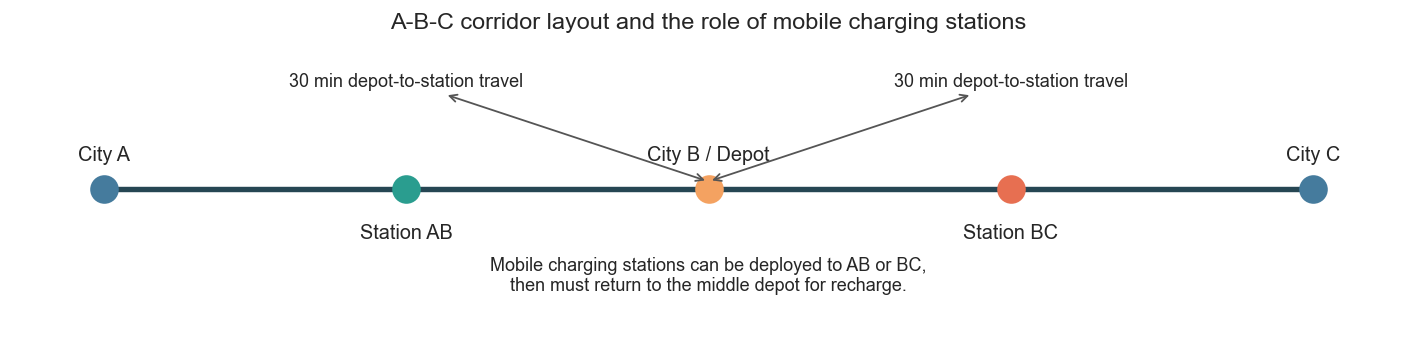

In [177]:
show_table(build_environment_overview_table(), precision=None)
fig, _ = plot_corridor_schematic()
plt.show()


The schematic highlights the key spatial constraint in the project. The depot is in the middle, while congestion may emerge on either side of the corridor. A controller therefore faces a real allocation problem: support sent to AB is not simultaneously available at BC, and vice versa.


<a id='simulation-design'></a>

## 3. Simulation design

This section builds the simulation environment step by step. The goal is not to copy every detail of a real EV charging network, but to create a small testbed where disruptions, queues, and mobile charging decisions can be studied clearly.

The final simulator combines six layers:

1. a simple A-B-C corridor,
2. time-varying traffic demand,
3. directional origin-destination flows,
4. stochastic charging and service,
5. mobile charging stations with travel and recharge delays,
6. disruption events that stress the system.

### 3.1 Base corridor

The starting point is the simplest spatial setting that still has local congestion: three cities on a line and one fixed charging station on each link. This gives two service points, AB and BC, that can become stressed differently.

### 3.2 Time-varying demand

Traffic demand is not constant during the day. The simulator therefore uses a deterministic daily demand profile as the expected traffic level, and then samples actual arrivals around this level.

The expected total traffic at time \(t\) is built as:

$$
\lambda(t)
=
\lambda_0
+
a_m \exp\left(-\frac{(t-\mu_m)^2}{2\sigma^2}\right)
+
a_l \exp\left(-\frac{(t-\mu_l)^2}{2\sigma^2}\right)
+
a_e \exp\left(-\frac{(t-\mu_e)^2}{2\sigma^2}\right)
$$

where:

- $\lambda_0$ is the baseline traffic level,
- $\mu_m$, $\mu_l$, and $\mu_e$ are the morning, midday, and evening peak times,
- $\sigma$ controls how wide the peaks are,
- $a_m$, $a_l$, and $a_e$ control the peak sizes.
In the active benchmark, the baseline is 26 cars per 5-minute step. The morning peak is centered around 08:00, the evening peak around 17:00, and the peak width is 1.6 hours.

The exact numbers are less important than the role of this layer: it creates normal variation in pressure, so that later we can separate normal congestion from disruption-driven congestion.

### 3.3 OD structure

The total expected traffic is split into origin-destination flows. Instead of treating all vehicles as one generic arrival stream, the simulator tracks six OD flows:

$$
AB,\ BA,\ BC,\ CB,\ AC,\ CA
$$

For each time step, the expected OD traffic is converted into realized arrivals using a Poisson draw:

$$
N_{od,t} \sim \mathrm{Poisson}(\lambda_{od,t})
$$

This means the daily profile is smooth in expectation, but the actual simulation is still random. That is important because queues in real systems do not grow perfectly smoothly.

### 3.4 Queueing and service

Not every passing vehicle needs to charge. For each OD flow, the number of vehicles that stop for charging is sampled as:

$$
C_{od,t} \sim \mathrm{Binomial}(N_{od,t}, p_{\mathrm{stop}})
$$

where the active benchmark uses:

$$
p_{\mathrm{stop}} = 0.055
$$

Charging vehicles are assigned to the relevant station depending on their OD route. Vehicles that cannot be served immediately join the queue. Service times are random:

$$
S \sim \mathrm{clip}\left(\mathcal{N}(30, 8^2), 15, 50\right)
$$

so the average charging session lasts 30 minutes, but very short and very long sessions are bounded.

### 3.5 Mobile charging stations

Mobile charging stations are added only after the fixed charging system exists. Their role is to add flexible capacity, not replace the fixed system.

The active benchmark uses up to 10 mobile charging stations, with 2 chargers per mobile unit. These units are not moved instantly. They can be at AB, at BC, in the middle depot, in transit, or temporarily unavailable because they need to recharge.

This means the control decision is spatial and delayed. Sending a mobile charger toward one station can help that station later, but it also makes the unit unavailable somewhere else in the meantime.

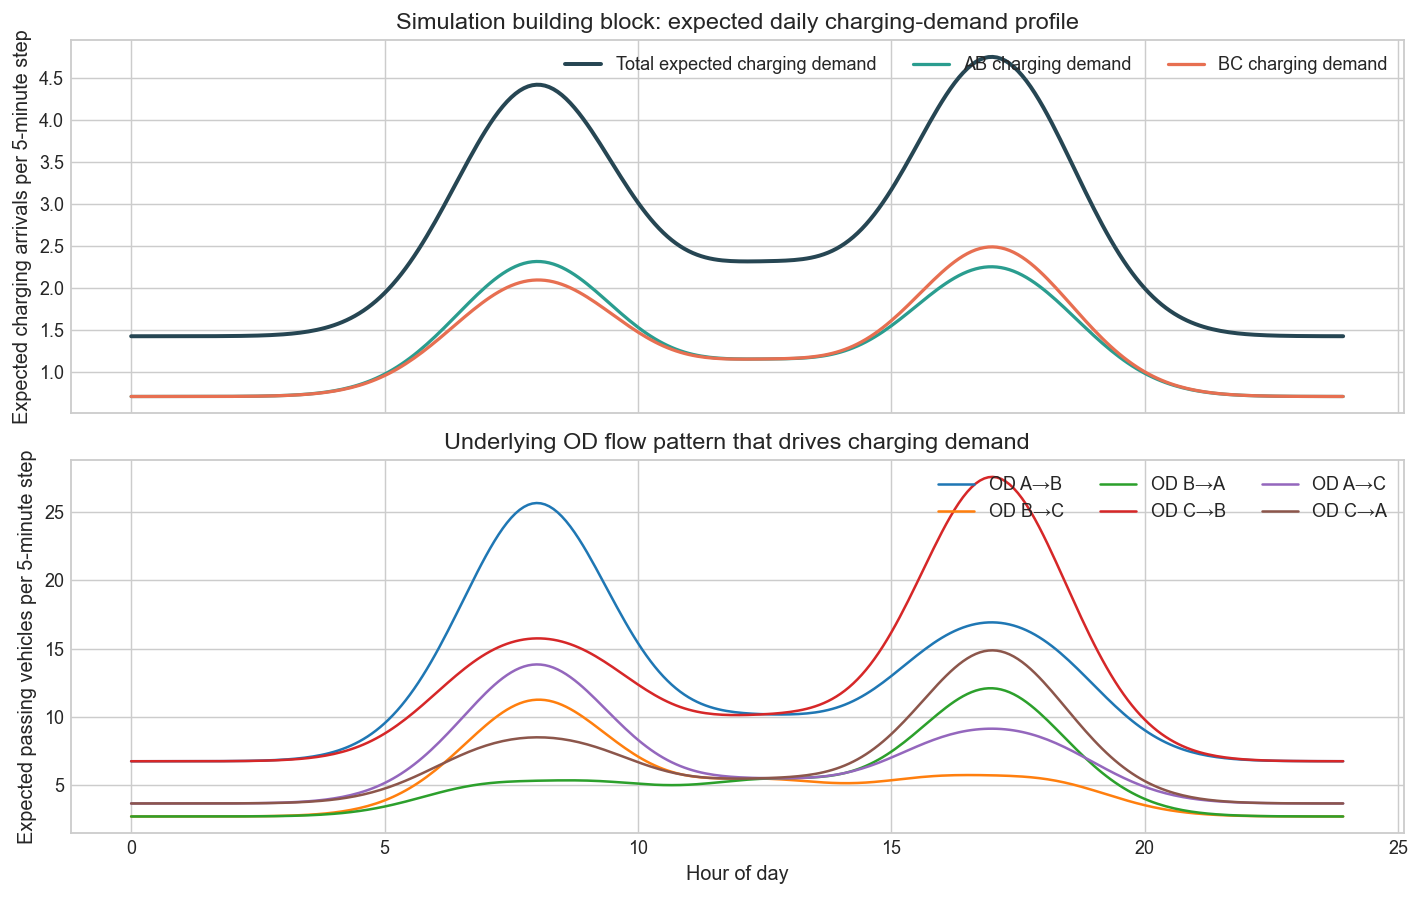

In [178]:
fig, _ = plot_demand_profile(daily_profile)
plt.show()


The demand plot is the first important building block. The top panel shows that expected charging demand is structured around a morning peak, an afternoon/evening peak, and a smaller midday bump. The lower panel shows the OD components that generate this pattern, which is why congestion can become directional rather than purely aggregate.


Two design choices deserve emphasis.

First, the simulator mixes deterministic structure and stochastic realization. The daily demand profile is interpretable, but arrivals and service times are still random. Second, disruptions are sampled from bounded ranges. That keeps the scenarios diverse enough to test robustness, while still allowing the examiner to understand what a disruption actually means in this benchmark.

The four subsections below switch from the full random benchmark to **scripted one-day examples**. Each example contains exactly one disruption type so its operational mechanism is easy to see. The goal is not to produce benchmark scores here, but to show how each disruption changes the relationship between expected demand, queue length, and queue wait.


### 3.6 Disruptions

Disruptions are the main stress mechanism in the benchmark. A disruption starts at time $t_s$, lasts for $d$ hours, and changes either local service capacity, service speed, or demand.

A disruption is active when:

$$
t_s \leq t < t_s + d
$$

The benchmark includes four disruption types.

#### 3.6.1 Capacity drop

A capacity drop reduces the number of usable fixed plugs at one station:

$$
K_i(t) =
\begin{cases}
K_i^{\mathrm{drop}}, & \text{if disruption is active at station } i \\
K_i, & \text{otherwise}
\end{cases}
$$

This creates local congestion without increasing demand. It is useful because it tests whether the system can recover when service capacity is reduced.


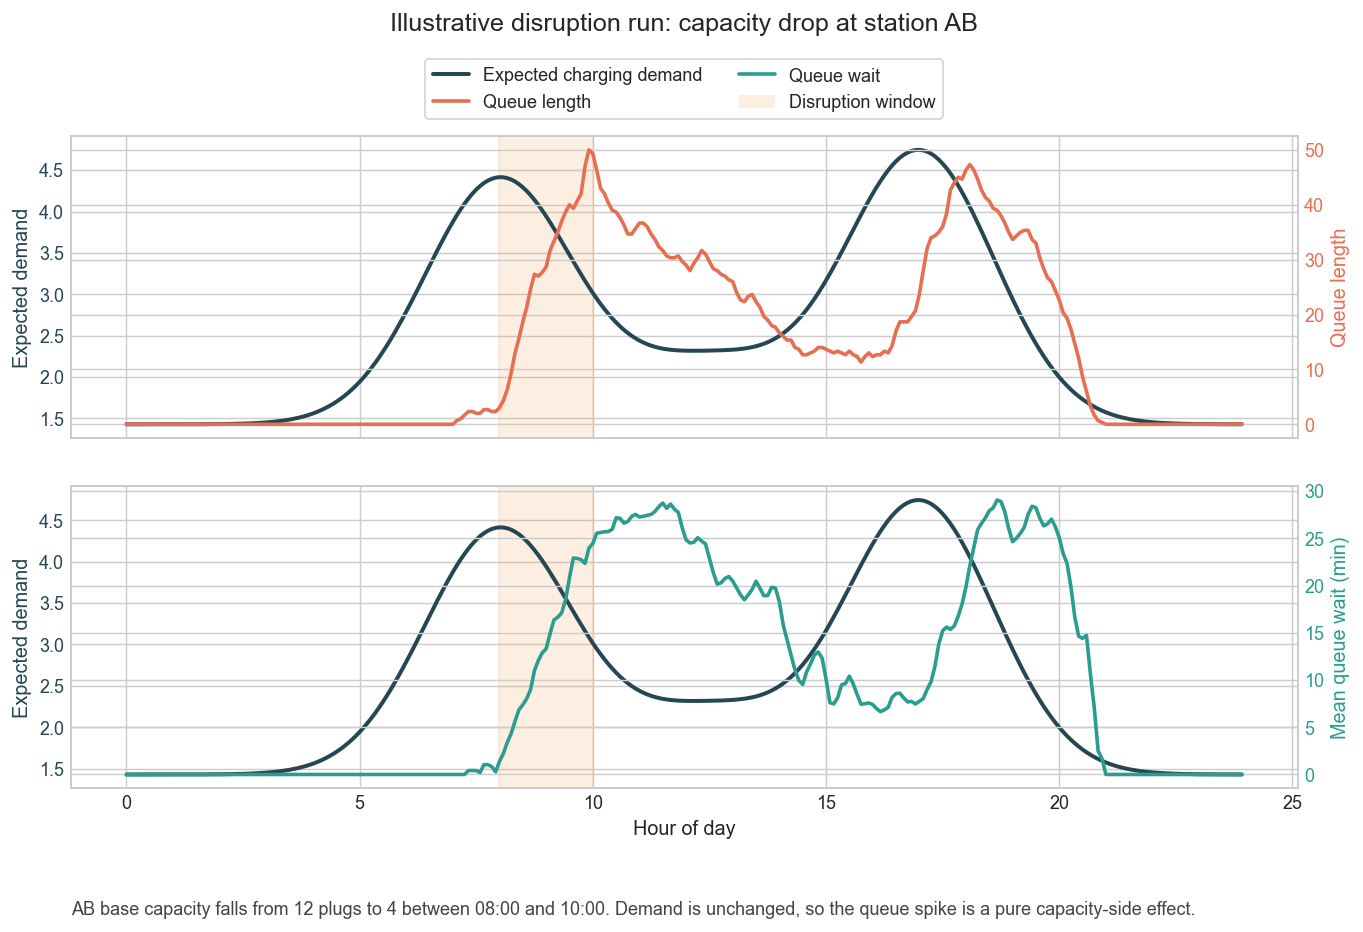

In [179]:
fig, _ = plot_disruption_scenario(
    disruption_case_runs['capacity_drop'],
    title='Illustrative disruption run: capacity drop at station AB',
    subtitle='AB base capacity falls from 12 plugs to 4 between 08:00 and 10:00. Demand is unchanged, so the queue spike is a pure capacity-side effect.',
    rolling_steps=3,
)
plt.show()


The expected-demand line remains on its normal path, while queue length and waiting time rise sharply inside the shaded window. That is the signature of a resilience problem driven by lost local service capacity rather than extra arrivals.


#### 3.6.2 Station outage

A station outage is the strongest version of a capacity-side disruption. The affected station is temporarily forced to zero fixed plugs:

$$
K_i(t) = 0
$$

during the disruption window.

This tests whether mobile charging stations can compensate for a hard local failure.

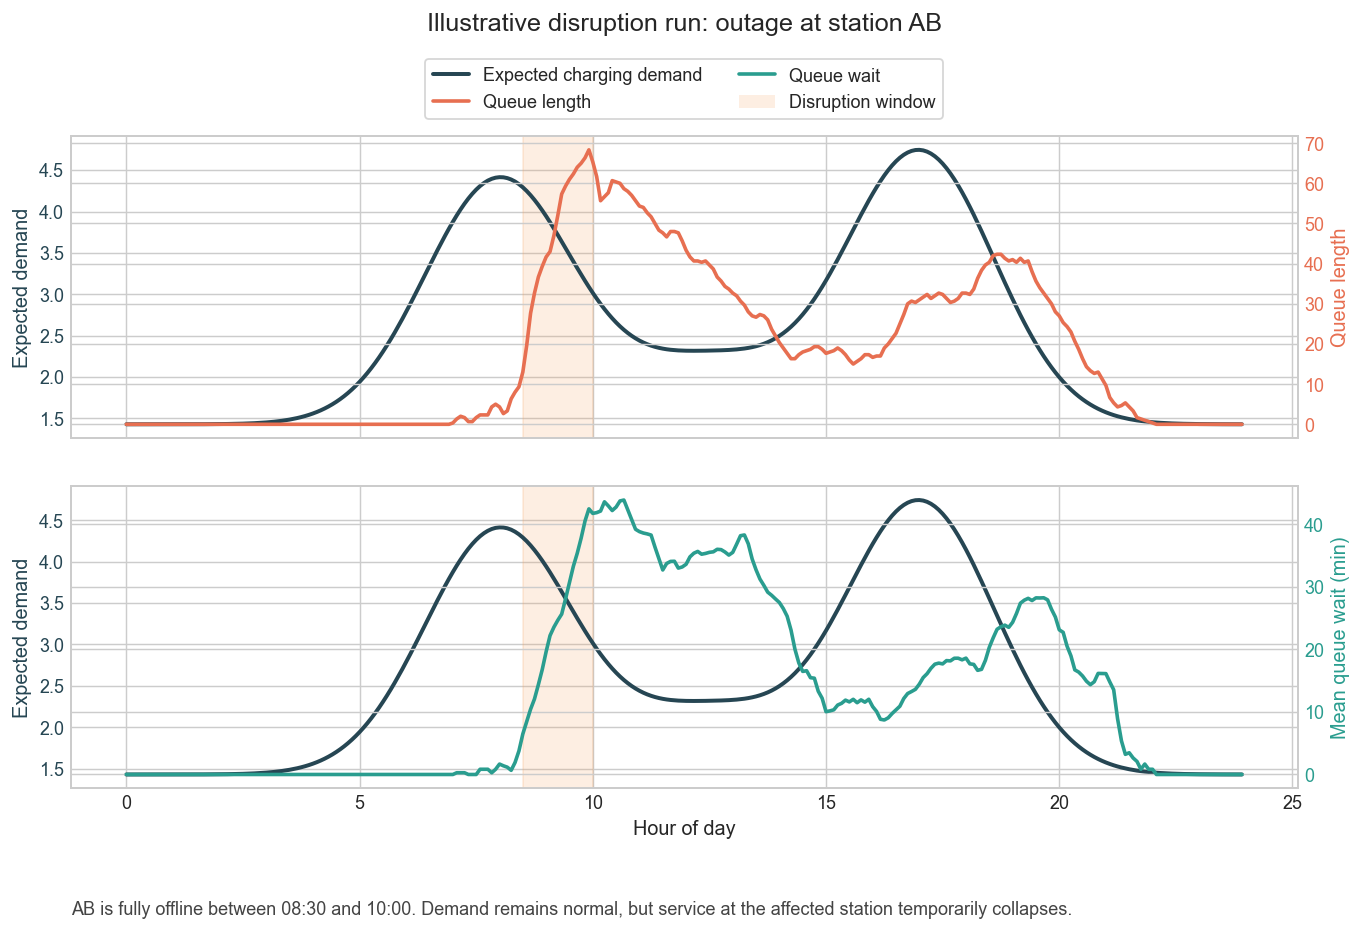

In [180]:
fig, _ = plot_disruption_scenario(
    disruption_case_runs['station_outage'],
    title='Illustrative disruption run: outage at station AB',
    subtitle='AB is fully offline between 08:30 and 10:00. Demand remains normal, but service at the affected station temporarily collapses.',
    rolling_steps=3,
)
plt.show()


This case produces the steepest queue response because effective local capacity falls all the way to zero. The demand path still does not move much, which makes the disruption effect especially easy to separate from ordinary morning congestion.


#### 3.6.3 Service-time inflation

Service-time inflation keeps the plugs available, but makes each charging session take longer:

$$
S'(t) = \alpha S
$$

where \(\alpha > 1\) during the disruption window.

This reduces effective throughput because plugs turn over more slowly, even though the physical station is still operating.


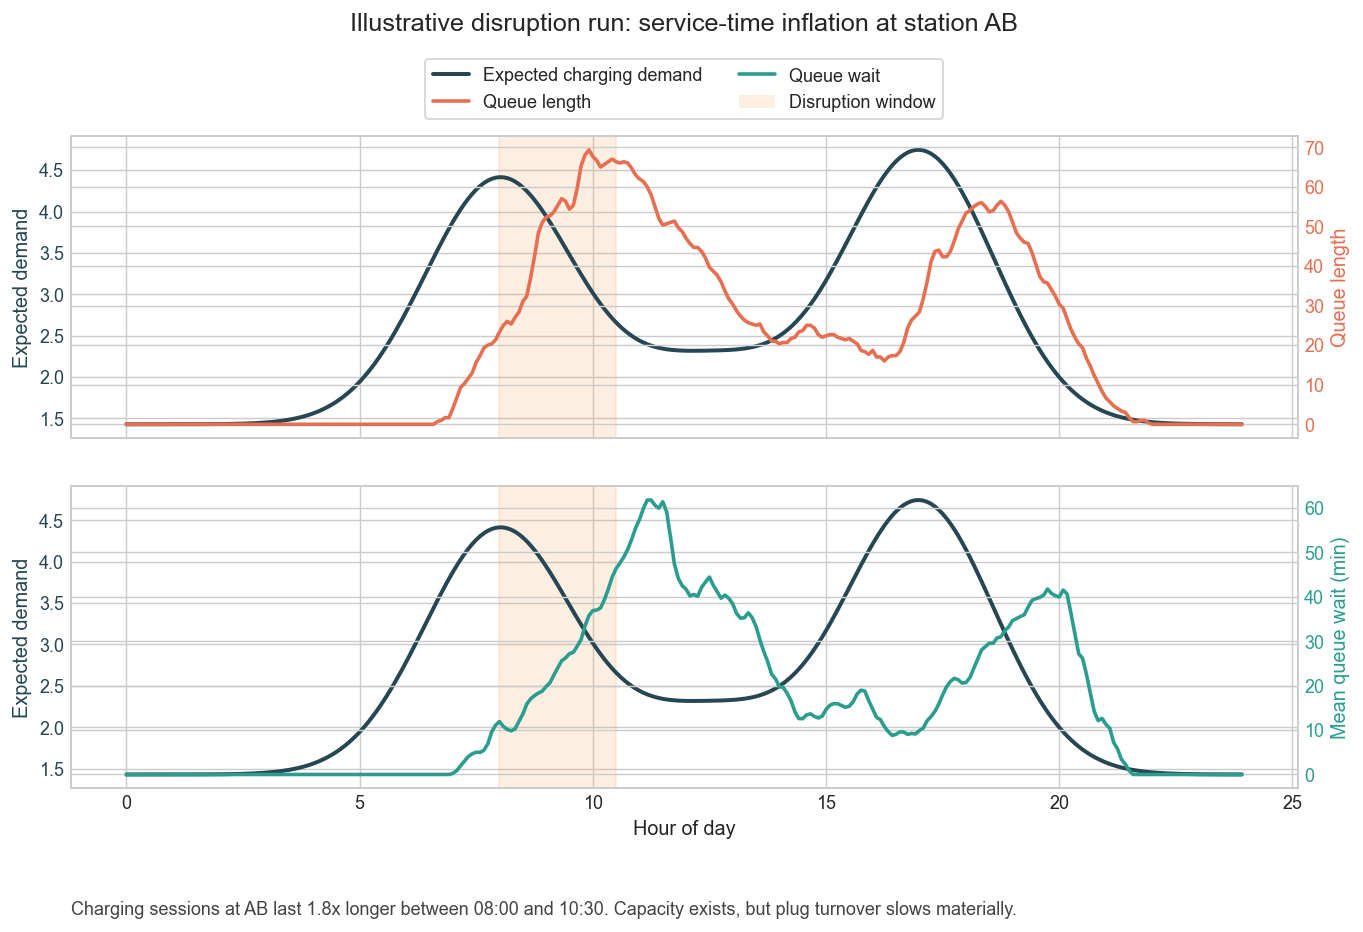

In [181]:
fig, _ = plot_disruption_scenario(
    disruption_case_runs['service_time_inflation'],
    title='Illustrative disruption run: service-time inflation at station AB',
    subtitle='Charging sessions at AB last 1.8x longer between 08:00 and 10:30. Capacity exists, but plug turnover slows materially.',
    rolling_steps=3,
)
plt.show()


The queue response is milder than a full outage but more persistent, because congestion builds through slower turnover rather than an immediate hard stop. This is a useful reminder that resilience problems can come from degraded service rates as well as from missing plugs.


#### 3.6.4 Demand surge

A demand surge changes the arrival side of the system. During the disruption window, selected OD flows are multiplied:

$$
\lambda'_{od,t} = \beta \lambda_{od,t}
$$

where \(\beta > 1\).

This creates congestion because more vehicles arrive, not because the station becomes slower or loses plugs.

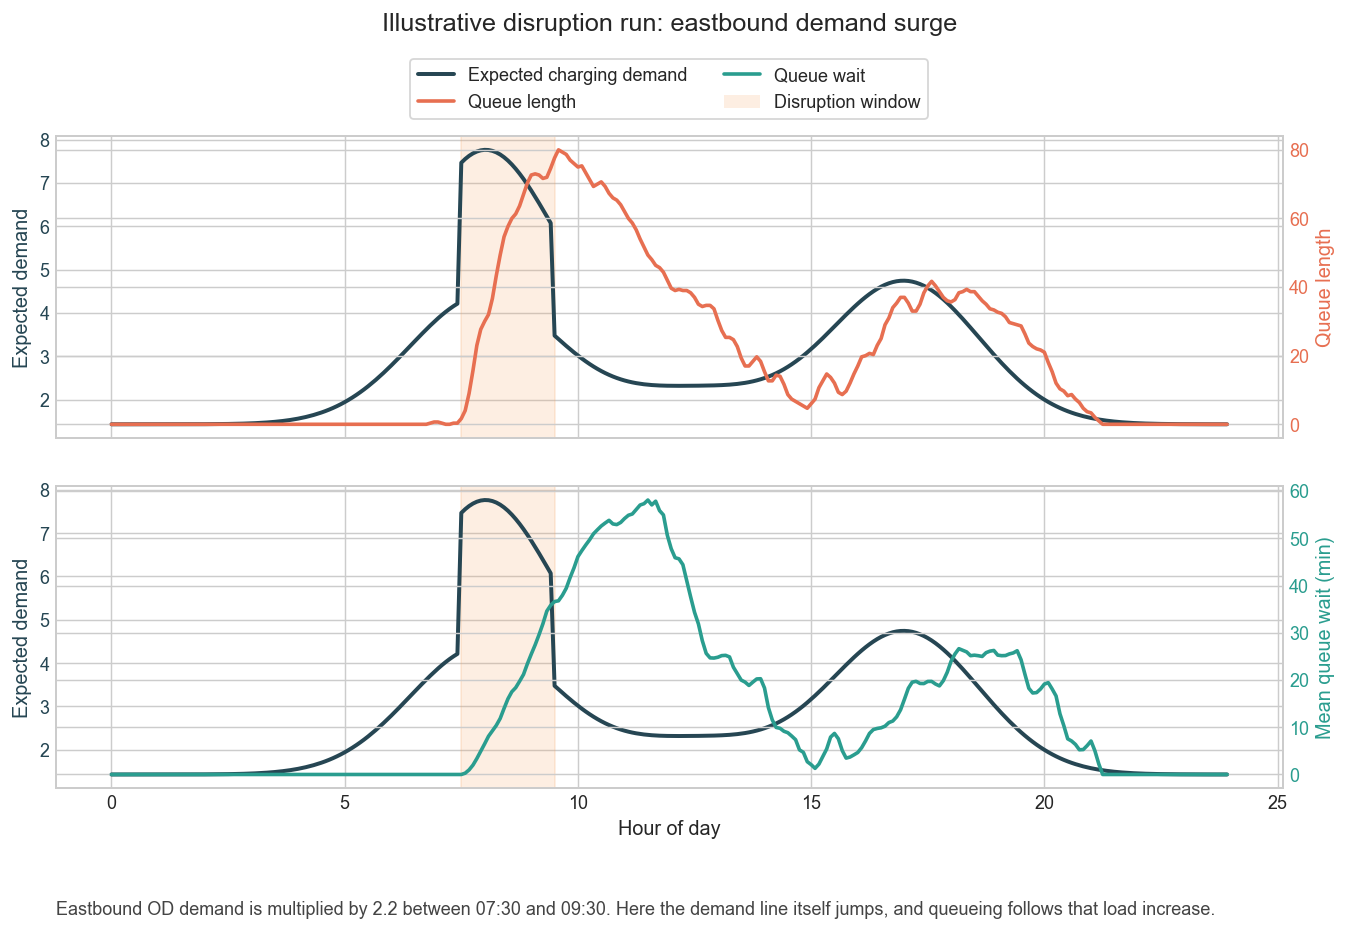

In [182]:
fig, _ = plot_disruption_scenario(
    disruption_case_runs['demand_surge'],
    title='Illustrative disruption run: eastbound demand surge',
    subtitle='Eastbound OD demand is multiplied by 2.2 between 07:30 and 09:30. Here the demand line itself jumps, and queueing follows that load increase.',
    rolling_steps=3,
)
plt.show()


This figure looks different from the previous three because the expected-demand line itself increases during the disruption window. That contrast is useful in the report: capacity-side disruptions create queue spikes without extra demand, while demand surges raise congestion by directly increasing the incoming load.


<a id='rl-agent-and-methods'></a>

## 4. RL agent and methods

_The figure from the draft export was removed in the cleaned repo version; the discussion below is unchanged._

The control problem is solved with an RL agent implemented in PyTorch. We use this model because the action space is small, the policy should be interpretable, and the method gives useful training diagnostics such as reward, TD loss, evaluation reward, and evaluation TD loss.

The agent observes the current state of the corridor and chooses one of five directional actions:

1. `hold`
2. `toward_ab`
3. `toward_bc`
4. `recall_ab`
5. `recall_bc`

This means the agent does not choose a full allocation of all mobile charging stations at once. Instead, it makes small directional decisions. It can hold the current deployment, move commitment toward AB or BC, or recall mobile capacity from one side.

This design fits the operational problem well. Mobile charging stations cannot appear instantly at a station, because they have travel and recharge delays. Therefore, the learning problem is not only about how many chargers are needed, but also where they should be sent before queues become too large.

### 4.1 RL-agent decision idea

The agent learns an action-value function:

$$
Q(s,a)
$$

where $s$ is the observed state of the corridor and $a$ is one of the five possible actions. The value $Q(s,a)$ estimates how good it is to take action $a$ in state $s$, considering both the immediate reward and future consequences.

At each step, the agent compares the current Q-value with a target value:

$$
y = r + \gamma \max_{a'} Q(s', a')
$$

where:

- $r$ is the reward from the current step,
- $s'$ is the next state,
- $a'$ is a possible next action,
- $\gamma$ is the discount factor.

The model is trained to reduce the difference between the predicted value and this target. In the implementation, this is done with Huber loss, also called smooth L1 loss:

$$
\mathcal{L} = \mathrm{Huber}\left(Q(s,a), y\right)
$$


### 4.2 Neural network

The Q-function is represented by a small multilayer neural network. The input is the observation vector from the environment, and the output is one Q-value for each possible action.

In the active setup, the model has:

- observation size: 27,
- action size: 5,
- network structure: 27 → 256 → 256 → 5,
- optimizer: Adam,
- loss function: Huber / smooth L1 loss.

The output layer has five values, one for each action. During evaluation, the agent chooses the valid action with the highest Q-value.

### 4.3 Exploration and replay buffer

During training, the agent uses epsilon-greedy exploration. This means that it sometimes chooses a random valid action instead of the action with the highest predicted Q-value. Early in training, this helps the agent try different deployment decisions. Later, exploration is reduced, so the agent relies more on what it has learned.

In our setup, exploration starts high and is gradually reduced:

$$
\epsilon_{\text{start}} = 1.0,
\qquad
\epsilon_{\text{end}} = 0.05
$$

This means the agent begins by exploring many different actions, but later mostly follows the action with the highest learned Q-value.

The agent also stores previous experience in a replay buffer. Each stored transition contains the current state, the chosen action, the reward, the next state, the next valid-action mask, and whether the episode ended:

$$
(s, a, r, s', \text{next\_action\_mask}, \text{done})
$$

The replay buffer can store up to 200,000 transitions. It does not keep old experience forever. When the buffer is full, the oldest transitions are replaced by newer ones.

Training does not start immediately. The agent first collects 10,000 environment steps, so the replay buffer contains enough experience before the first gradient updates are made.

After this, the Q-network is updated by sampling random mini-batches from the replay buffer. In our setup, each mini-batch contains 128 transitions. The agent updates every 4 environment steps and performs 4 gradient steps each time, which gives roughly one gradient update per environment step after learning starts.

This makes learning more stable because the model does not only learn from the most recent step. Instead, it learns from a mix of earlier and newer experiences, including both good and bad actions. Bad actions are still useful because they help the model learn which choices lead to poor rewards and should receive lower Q-values.

The replay-buffer setup follows the standard reinforcement-learning idea described in the [TorchRL replay-buffer tutorial](https://docs.pytorch.org/rl/0.4/tutorials/rb_tutorial.html), where data collected from the environment is temporarily stored and later sampled as training data for the loss function.

### 4.4 Valid actions

Some actions may not be possible in every state. For example, the agent cannot recall mobile charging stations from AB if none are committed there. The environment therefore provides a valid-action mask.

The agent uses this mask both when exploring and when choosing the best action. This prevents the model from learning from actions that are operationally impossible.

### 4.5 Why this model fits the project

This model is suitable for the project because the main question is not to learn a very complex black-box policy. The goal is to test whether the RL agent can learn useful deployment behavior in a disrupted corridor.

The simple DQL setup is enough to study three things:

1. whether the agent can reduce queues and waiting times under disruptions,
2. whether the learned behavior changes when the reward function changes,
3. whether the agent reacts spatially by sending mobile charging capacity toward the stressed part of the corridor.

The model is therefore kept deliberately simple, so the results are easier to explain and connect back to the resilience problem.


### State space

The observation is 27-dimensional. The model is given local queue pressure, recent flow, effective local capacity, mobile-station logistics, disruption indicators, and time-of-day information. This means the policy can react to where pressure is building without relying on a hand-crafted oracle signal. The full 27-feature state definition is listed in Appendix A.


In [183]:
show_table(build_state_group_table(), precision=None)


| Feature group | Count | Why it is in the state |
| --- | --- | --- |
| Queue state | 4 | Current queue length and current mean wait at AB and BC. |
| Recent flow | 4 | Latest arrivals and latest service starts at each station. |
| Capacity state | 4 | Effective plugs and active mobile capacity at AB and BC. |
| Spatial pressure | 4 | Committed MCS bias and local deficit estimates by side of corridor. |
| Disruption state | 4 | Whether a disruption is active, what type it is, and which side it affects. |
| MCS logistics | 5 | Units available in depot, charging, or in transit to AB, BC, or middle. |
| Time-of-day | 2 | Sine and cosine encodings of time within the day. |

### Action space

The active action space has five commands: hold, move one unit toward AB, move one unit toward BC, recall one unit from AB, and recall one unit from BC. This should be read as a deliberate modeling choice, not a reduced convenience version. It keeps the controller focused on directional decisions that respect depot availability and relocation lag.

A subtle but important detail is that the environment itself decides whether a `toward_ab` command is satisfied from the middle depot or by shifting one committed unit from BC. The policy chooses the **directional intent**; the environment resolves the **physical logistics**.


In [184]:
show_table(action_table(), precision=None)


| Action | Interpretation |
| --- | --- |
| hold | Keep the committed mobile-station allocation unchanged. |
| toward_ab | Move one unit of commitment toward AB, either from depot or from BC. |
| toward_bc | Move one unit of commitment toward BC, either from depot or from AB. |
| recall_ab | Recall one committed unit away from AB toward the middle depot. |
| recall_bc | Recall one committed unit away from BC toward the middle depot. |

### Reward function and loss function

The reward combines service-quality incentives and operating-cost penalties.

The positive terms reward the agent for serving vehicles, using capacity productively, and placing mobile support where local deficits are estimated to be highest. The negative terms penalize queueing, waiting, unmet demand, unnecessary MCS activation, repeated adjustment, and carrying idle capacity.

This distinction matters because **operational performance** and **reward** are related but not identical. A policy may reduce queueing substantially while still earning a poor total reward if it uses too much costly mobile capacity.

The RL agent is trained with a **Huber TD loss** (`smooth_l1_loss`). Intuitively, the model predicts action values, compares them with one-step bootstrap targets, and updates the network to reduce that temporal-difference error. Huber loss is used because it is less brittle than pure squared error when RL targets are noisy.


In [185]:
positive_reward_table, negative_reward_table = build_reward_term_tables()
show_table(positive_reward_table, precision=2)
show_table(negative_reward_table, precision=2)


| Positive term | Weight | Operational role |
| --- | --- | --- |
| served_reward_weight | 1.0 | Rewards charging sessions that start service. |
| utilization_bonus | 1.0 | Rewards productive use of available charging capacity. |
| spatial_deficit_alignment_bonus | 24.0 | Rewards mobile capacity that covers estimated local deficits. |
| spatial_deficit_direction_bonus | 12.0 | Rewards sending MCS in the correct corridor direction. |

| Negative term | Weight | Operational role |
| --- | --- | --- |
| unmet_penalty | 2.5 | Penalizes vehicles left in queue after the step. |
| queue_length_penalty | 2.5 | Adds extra pressure against persistent queue accumulation. |
| queue_wait_penalty | 0.02 | Penalizes queue-wait burden, not just queue count. |
| local_queue_peak_penalty | 1.0 | Penalizes the worst station queue in the step. |
| local_wait_peak_penalty | 0.1 | Penalizes the worst station waiting time in the step. |
| active_mobile_station_cost | 18.0 | Charges for keeping MCS active in the field. |
| activation_cost | 2.0 | Charges for newly activating MCS. |
| adjustment_cost | 0.5 | Charges for reallocating MCS commitment. |
| idle_capacity_penalty | 0.1 | Penalizes carrying unused capacity. |

<a id='reward-calibration'></a>
## 5. Reward calibration

Reward calibration is a core modeling choice in this project. Mobile charging can reduce queues, but it also represents operating cost. The two generated sweeps below now use the **actual five-run HPC results** copied into `exam_submission/data/generated/reward_sweeps/`.

This makes the section much cleaner: one sweep changes only MCS cost, and one sweep changes only queue cost. For each sweep, the notebook shows how queue length and queue wait respond to the reward calibration used during training.


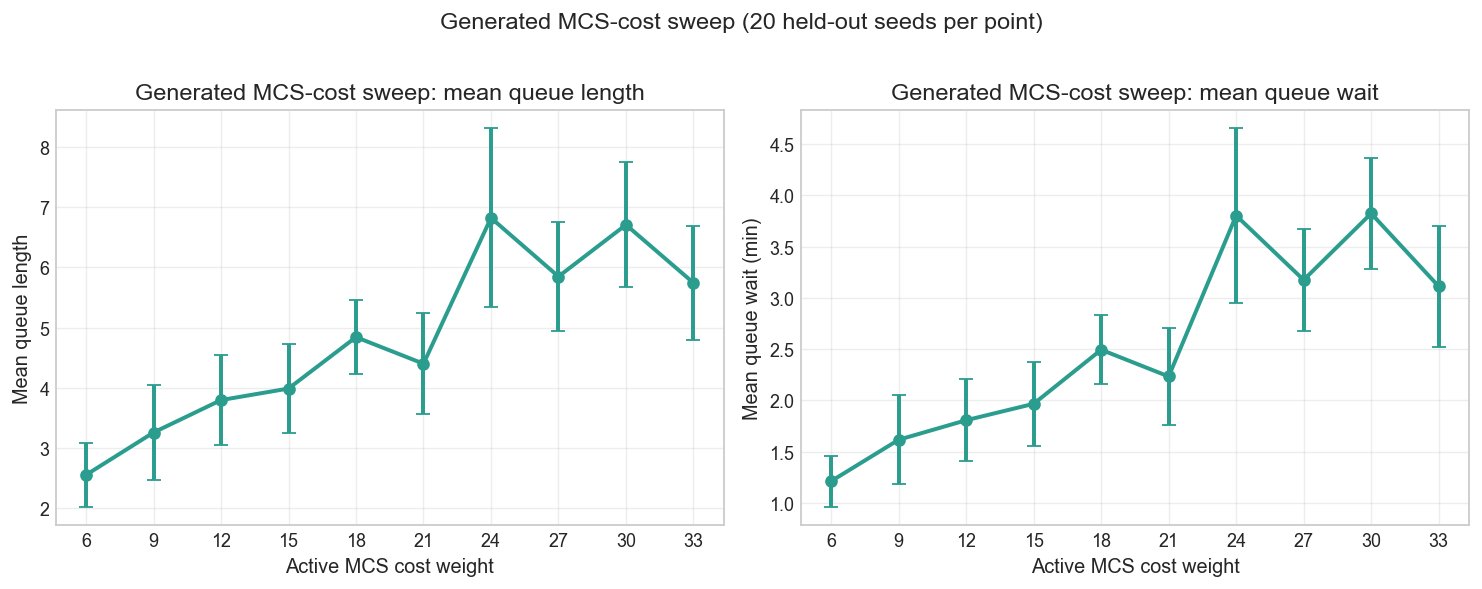

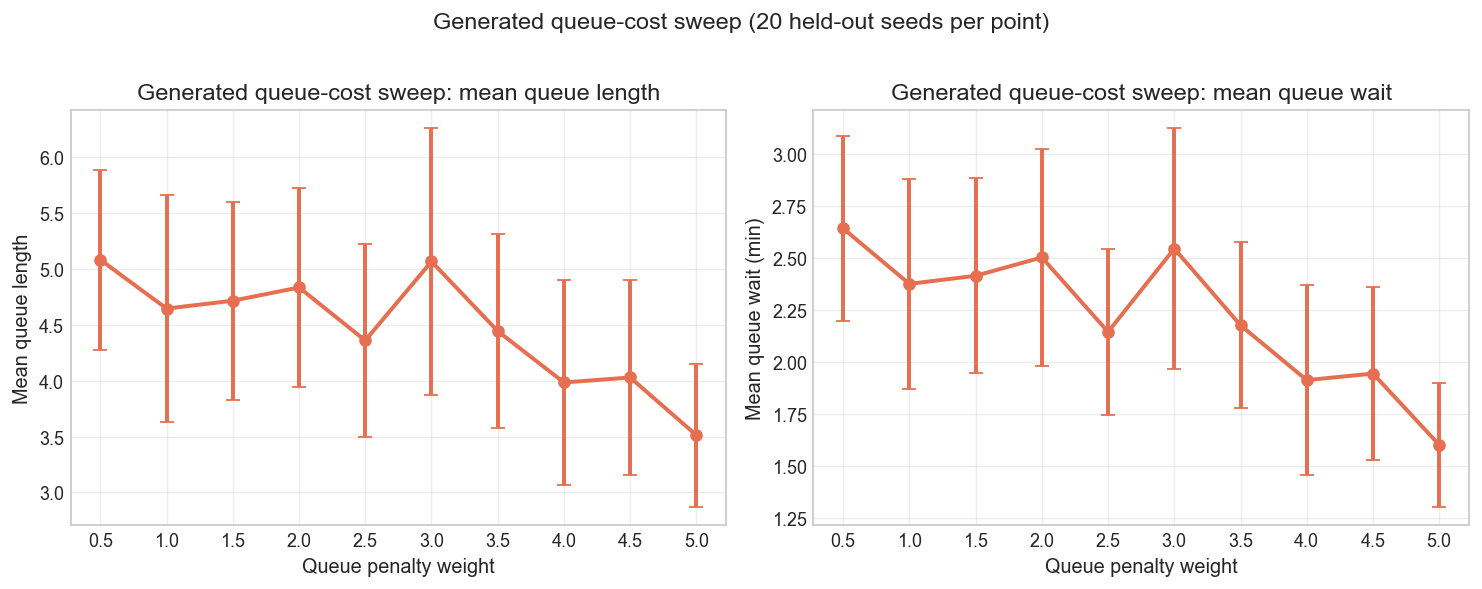

In [186]:
fig, _ = plot_generated_reward_sweep(generated_reward_sweeps.get('mcs_cost'), x_label='Active MCS cost weight', title='Generated MCS-cost sweep', color='#2A9D8F')
plt.show()
fig, _ = plot_generated_reward_sweep(generated_reward_sweeps.get('queue_cost'), x_label='Queue penalty weight', title='Generated queue-cost sweep', color='#E76F51')
plt.show()


These plots now use the copied **multi-seed aggregate** sweep results.

- Each point is the mean over the held-out seeds used in the multiseed evaluation.
- The vertical error bars show the standard deviation across those held-out seeds.
- The tables below each figure report both the mean and the spread, which makes the uncertainty much clearer than the old single-seed version.

This is a more defensible way to discuss reward calibration, because it separates the average operating point from scenario-to-scenario variability.


<a id='training-setup'></a>

## 6. Training setup

The training pipeline separates training episodes, periodic evaluation, held-out rollouts, and named stress scenarios.

- **Training** uses randomized episodes from the benchmark distribution.
- **Periodic evaluation** checks the current policy on held-out seeds without exploration and without learning updates.
- The **held-out rollout** is the final time-series comparison used in the main report.
- **Stress scenarios** are scripted one-day disruptions used as robustness checks and are kept in the appendix.

Even without hyperparameter tuning or early stopping, periodic evaluation is still useful. It shows whether the policy is improving on held-out scenarios rather than only fitting the randomness of the latest training episodes.


In [187]:
show_table(build_training_setup_table(), precision=None)


| Component | How it is used in this report |
| --- | --- |
| Training episodes | Randomized 2-6 day episodes sampled from training seeds 0-9999. |
| Periodic evaluation | 10 held-out episodes every 15000 environment steps without exploration or learning updates. |
| Validation split | Configured held-out validation seeds starting at 10000; useful for policy checks even without hyperparameter tuning. |
| Held-out rollout | A fixed unseen `test_id` scenario used for the main time-series comparison in this report. |
| Test stress suite | Named one-day scripted disruptions used for robustness checks; kept in the appendix to avoid clutter. |

<a id='training-the-model'></a>

## 7. Training the model

The reported model is referred to throughout this notebook as the RL agent. However, the current repository snapshot does not contain a compatible checkpoint for the active benchmark, so the notebook cannot load and roll out that policy directly.

What **is** available is a copied current training-history artifact. That artifact contains train reward, train TD loss, evaluation reward, and evaluation TD loss. These diagnostics are therefore used as evidence about whether the RL learner improved during training.

A separate appendix demo shows how an examiner can launch a short local train/eval run from a single helper function. That appendix demo is intentionally illustrative only and is not used as evidence for the reported results in the main body.


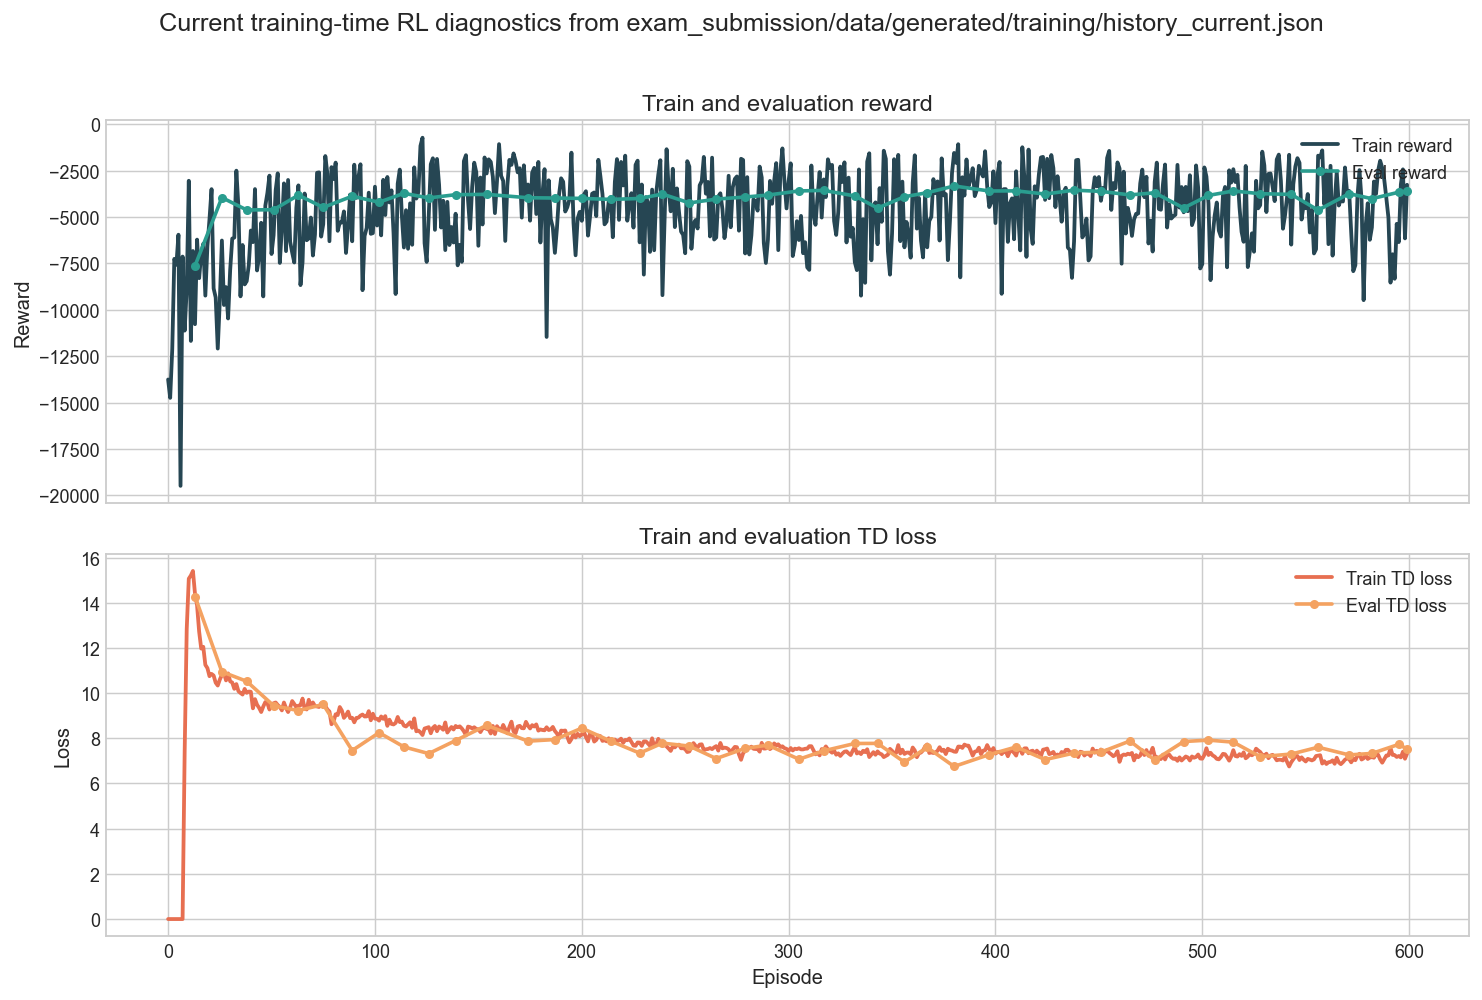

In [188]:
fig, _ = plot_training_history(training_history, source=training_history_source)
plt.show()


The learning curves should be interpreted carefully.

- Train reward and TD loss are noisy, as expected in RL.
- Evaluation reward is more informative than raw training reward because it is measured without exploration.
- Evaluation TD loss is not a supervised validation loss, but it is still useful as a consistency check on the learned value function.

The copied history suggests that the RL agent improved relative to its very poor early episodes and reached a more stable regime. However, because the compatible final checkpoint is missing, the report cannot make a final reproducible claim about RL rollout performance on the active benchmark.


The short local demo is now kept in **Appendix B**. There, the notebook calls `run_appendix_demo()` from `exam_submission/utils/demo_runner.py`, which trains briefly, plots train/eval reward and TD loss, and then runs one held-out test rollout for inspection.


<a id='simulation-comparison-rollout'></a>

## 8. Simulation comparison rollout

The intended main comparison was fixed-only capacity versus the final RL controller. Because no current-compatible RL rollout artifact is present in the checkout, that exact comparison cannot be reproduced honestly in this notebook.

To keep the report reproducible, the main operational comparison below uses:

- the **fixed / no-agent baseline**, and
- the **RL agent**, which is the currently copied rollout artifact used throughout the notebook.

This still answers an important resilience question: does the RL agent materially reduce queueing pressure relative to the no-agent baseline? The appendix retains the reactive rule as secondary context, but it is removed from the main section to keep the story clean.


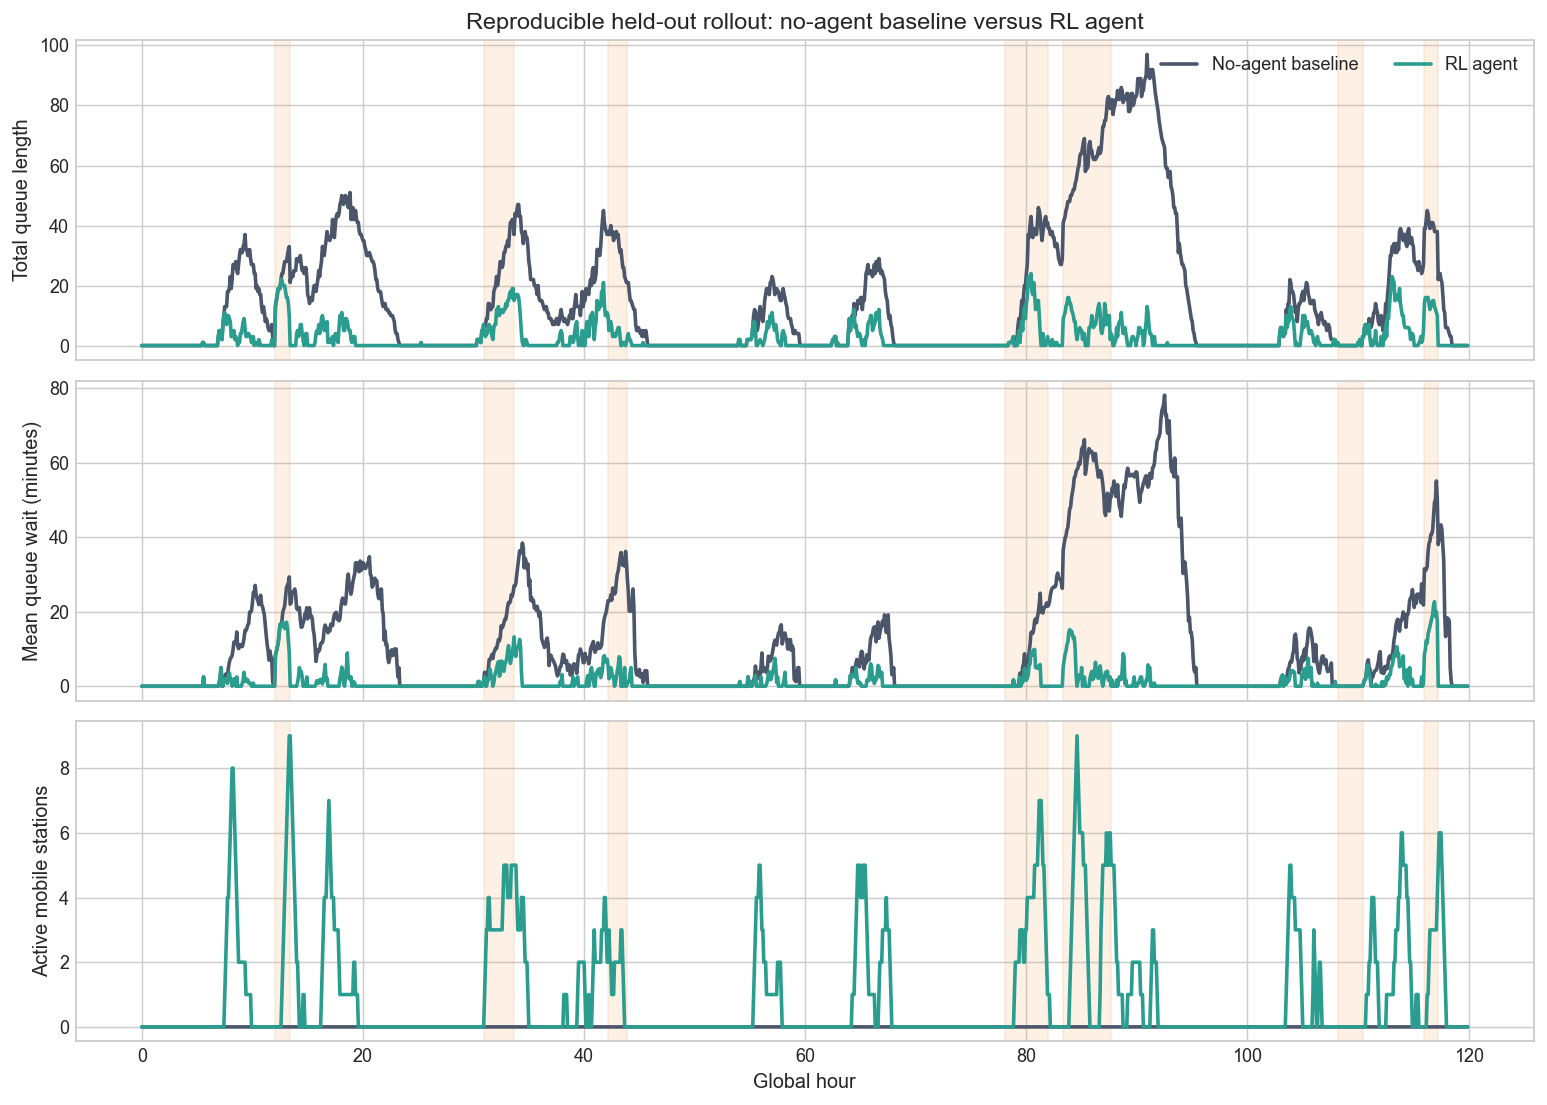

In [189]:
main_frames = {name: heldout_frames[name] for name in MAIN_POLICIES}
fig, _ = plot_main_rollout_comparison(main_frames)
plt.show()


The held-out rollout shows a clear operational improvement. Fixed capacity alone allows queue length and waiting time to build up substantially during disruption windows. The RL agent responds by activating mobile support, which reduces both total queueing and average waiting time.

The plot also illustrates the cost side of the problem: queue improvement is achieved by using MCS, not by creating capacity from nowhere. That is why the reward section and the reward-calibration section matter for interpretation.


<a id='summary-metrics-table'></a>

## 9. Summary metrics table

The table below summarizes the held-out rollout used in the main comparison. Breach-rate columns are shown for completeness, but they are not informative in the active exported artifacts because the queue-wait target is zero throughout the rollout files.


In [190]:
show_table(build_main_results_table(), precision=2)


| Policy | Mean queue | Peak queue | Mean wait (min) | Peak wait (min) | Breach rate | Started sessions | Mean active MCS | MCS hours | Reward | Queue improvement vs fixed (%) | Wait improvement vs fixed (%) | Reward change vs fixed |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| No-agent baseline | 16.6 | 97.0 | 12.37 | 78.14 | 0.0 | 3851.0 | 0.0 | 0.0 | -15969.37 | 0.0 | 0.0 | 0.0 |
| RL agent | 2.65 | 24.0 | 1.28 | 22.69 | 0.0 | 3846.0 | 0.95 | 113.5 | -4202.84 | 84.06 | 89.62 | 11766.53 |

The key result is that the RL agent meaningfully reduces queueing pain relative to fixed-only operation. The RL agent improves service outcomes while using much less mobile support than the more aggressive reactive rule shown later in the appendix. That makes it the cleanest main comparator among the currently reproducible artifacts used here.


<a id='spatial-awareness'></a>

## 10. Spatial awareness

A spatially aware controller should allocate support where local pressure is highest. In this corridor, that means MCS at AB should increase when AB has higher local demand or queue pressure, while MCS at BC should increase when BC is more stressed.

The RL agent is the clearest current artifact for checking this. The plots below show one-hour rolling averages of expected station demand, local queue length, and MCS allocation for AB and BC separately.


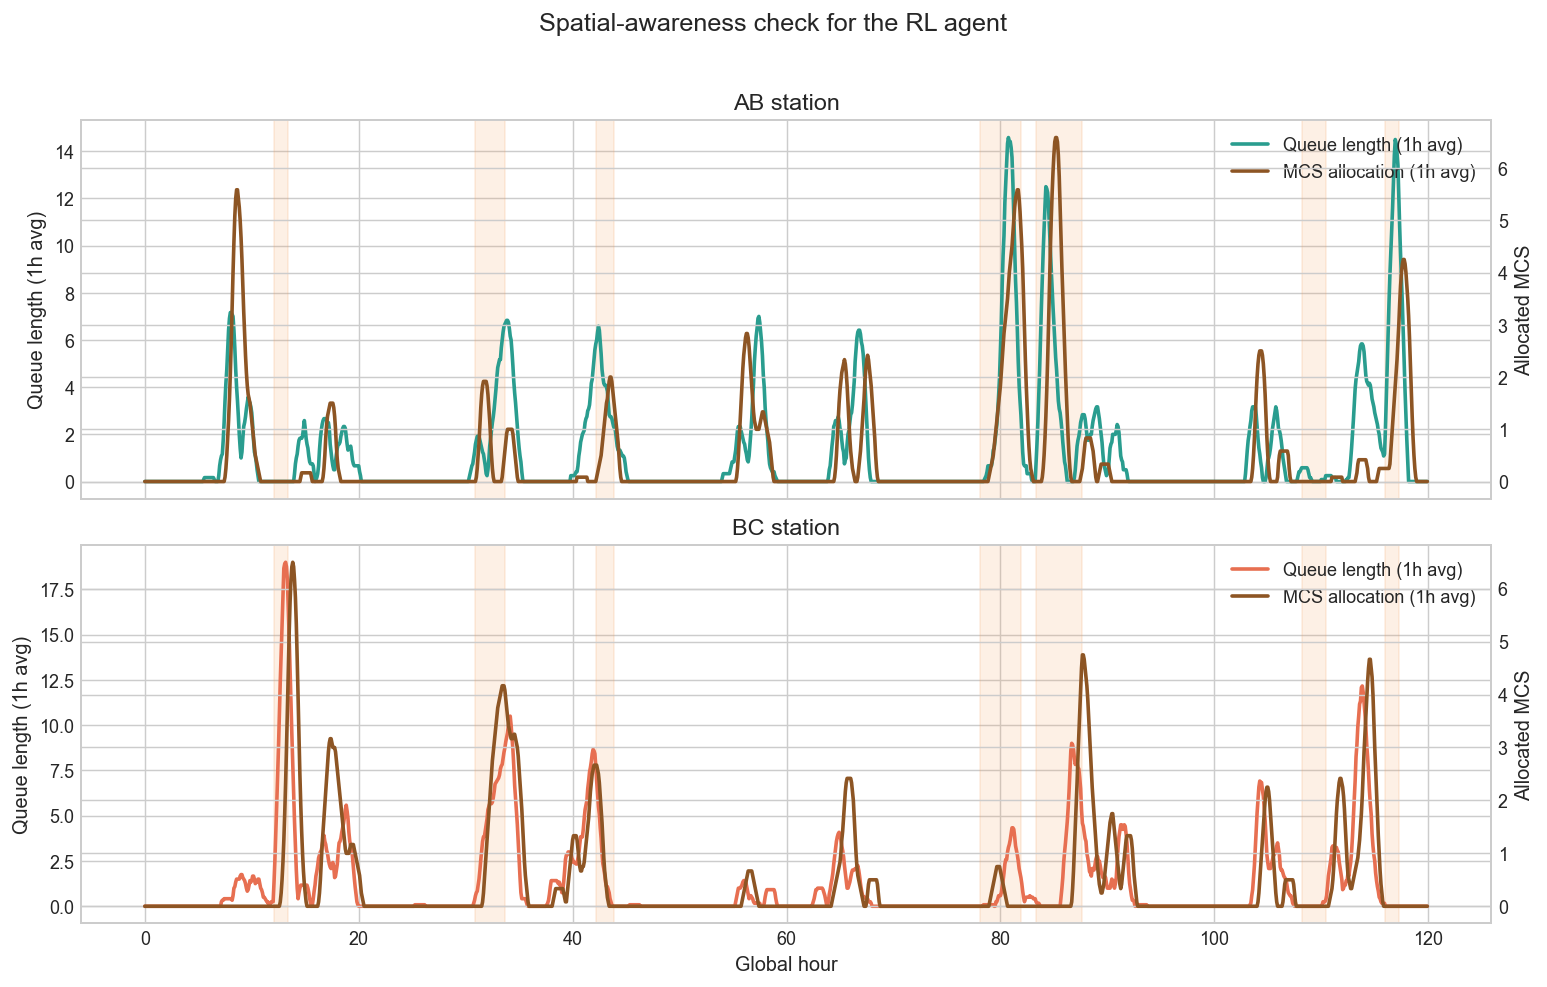

In [191]:
fig, _ = plot_spatial_station_overlays(heldout_frames['mobile_threshold'], rolling_steps=12)
plt.show()


The spatial response is meaningful but not perfect.

- When local pressure rises, MCS allocation generally rises on the same side of the corridor.
- The response is not instantaneous, which is expected because MCS units must travel and recharge.
- The relationship is clearer for the RL agent than for the reactive rule, because the reactive policy tends to keep many units active system-wide rather than expressing a clean directional response.

So the appropriate claim is not “perfect spatial awareness”. A more defensible conclusion is that the current simulator can reveal spatial behavior clearly, and the RL agent artifact shows a visible directional response to local service pressure.


<a id='limitations'></a>

## 11. Limitations

Several limitations are important and should be stated directly.

1. **The simulator is synthetic.** It is designed to be operationally meaningful, but it is not a calibrated production model of a real EV corridor.
2. **The current checkout lacks a compatible RL checkpoint.** The RL formulation and training diagnostics are available, but a final reproducible RL-vs-baseline rollout claim cannot be made from this repository snapshot alone.
3. **Reward sensitivity is substantial.** Different cost weights can change the preferred behavior significantly, especially the willingness to keep MCS active.
4. **Spatial behavior is partial rather than perfect.** Travel delay, recharge delay, directional symmetry, and cost all weaken one-to-one alignment between local pressure and instantaneous allocation.
5. **Logistics are simplified.** The simulator captures relocation and recharge delays, but not the full operational complexity of staffing, road-network uncertainty, or battery degradation.
6. **Stress coverage is limited.** The appendix shows several scripted stress scenarios, but this is still a bounded test set rather than a full uncertainty analysis over all possible disruptions.

These limitations do not invalidate the project, but they do constrain what can be claimed. The report therefore focuses on what is actually supported by the copied artifacts.


<a id='conclusion'></a>

## 12. Conclusion

This project studied whether mobile charging stations can improve resilience in an EV charging corridor when the system is exposed to disruptions. The final simulator combines an A-B-C corridor, stochastic charging demand, station-level queues, mobile charging station logistics, and four disruption types: capacity drops, station outages, service-time inflation, and demand surges.

The main idea was to test whether an RL-based controller can use mobile charging stations as flexible capacity instead of relying only on fixed infrastructure. The results support this idea. Compared with the fixed / no-agent baseline, the RL agent strongly reduces both queue length and waiting time in the held-out rollout.

The fixed baseline has a mean queue length of 16.60 vehicles and a mean waiting time of 12.37 minutes. With the RL agent, the mean queue length falls to 2.65 vehicles and the mean waiting time falls to 1.28 minutes. This corresponds to an 84.06% reduction in mean queue length and an 89.62% reduction in mean waiting time. Peak congestion is also reduced: the peak queue falls from 97 vehicles to 24 vehicles, and peak waiting time falls from 78.14 minutes to 22.69 minutes.

This answers the first research question:

**Resilience under disruptions:**  
The RL agent improves resilience because it keeps the charging system much more stable when disruptions occur. The baseline system reacts passively, so queues can grow large when capacity is reduced or demand increases. The RL agent uses mobile charging stations to add flexible capacity when the system becomes stressed. It does not eliminate all queues, but it reduces both average and peak congestion substantially. This means the system becomes better at continuing to serve vehicles when local conditions deteriorate.

The improvement is not caused by serving many more vehicles overall. The fixed baseline starts 3851 charging sessions, while the RL agent starts 3846. The important difference is instead *how* service is distributed over time and space. The RL agent prevents queues from becoming as large, which means similar service volume is achieved with much lower waiting time. This is exactly the kind of behavior we want from a resilience controller.

The second research question was about reward-function adaptability:

**Adaptability to operational preferences:**  
The reward calibration results show that the model behavior changes when the cost structure changes. This is important because a company such as Clever would not only care about reducing queues; it would also care about the cost of deploying and operating mobile charging stations. The reward function therefore includes both service-quality terms and MCS cost terms.

The reward sweep shows that different cost and queue-penalty settings lead to different operating points. Some configurations produce very low queues and waiting times but use more mobile capacity. Other configurations accept higher queueing in exchange for lower or different MCS usage. For example, the tested configurations range from very low mean queue values around 0.12–0.62 vehicles to higher mean queue values above 5 vehicles, depending on the reward weights. Mean waiting time also changes clearly across configurations.

This means the model is not locked to one fixed operating strategy. Instead, the reward function can be adjusted to reflect different business preferences. If queueing and customer waiting time are considered very expensive, the reward can push the agent toward more active use of MCS. If mobile deployment is costly, the reward can make the agent more conservative. The project therefore shows that the RL setup can represent different operational trade-offs, even though the final choice of reward weights would need to be calibrated with real company cost data.

The third research question was about spatial awareness:

**Spatially aware control:**  
The spatial plots show that the RL agent does not only improve aggregate system performance. It also reacts to where pressure appears in the corridor. When queue pressure increases at AB, mobile capacity is allocated toward AB. When pressure is stronger at BC, the allocation shifts toward BC. This is important because the corridor problem is not just a total-capacity problem. One station can be stressed while the other still has spare capacity, so the controller must learn where support is needed.

The spatial response is not perfect, and it should not be expected to be perfect. Mobile charging stations have travel delay, recharge delay, and operating costs. Therefore, the agent cannot instantly match every local queue spike. Sometimes it may also avoid moving capacity if the expected benefit is too small compared with the cost. Still, the station-level plots show clear evidence that MCS deployment is connected to local demand and queue pressure. This supports the claim that the model has learned spatially meaningful behavior rather than only reducing the total average queue.

Overall, the project shows that mobile charging stations can create a more resilient EV charging setup under disruptions when they are controlled adaptively. The strongest result is the large reduction in waiting time and queue length compared with fixed infrastructure alone. The reward experiments also show that the same modeling framework can be adjusted to different business trade-offs, and the spatial analysis shows that the agent reacts to the location of pressure in the corridor.

The main limitation is that the simulator is synthetic. It is designed to be realistic enough to study the control problem, but it is not calibrated to real traffic and charging data from an actual corridor. The exact numerical results should therefore not be interpreted as direct real-world forecasts. Instead, they should be read as evidence that the RL control idea works in a controlled disruption testbed.

At the same time, the model adapted convincingly to the complexity that was built into the simulation: stochastic demand, local queues, delayed MCS movement, recharge periods, different disruption types, and changing reward-function trade-offs. This is an important result because the real world is even more complex. If an RL agent can learn useful behavior in a simulation with many interacting constraints, it suggests that the same approach could be scaled toward more realistic decision problems where manual rules become difficult to design.

This is where reinforcement learning is especially relevant. As the system becomes larger, with more stations, more vehicles, more disruption patterns, and more operational costs, the number of possible decisions grows quickly. At some point, the problem becomes too complex for humans to solve with simple fixed rules. An RL-based approach can instead learn from repeated interaction with the environment and adjust its decisions based on the full system state.

The final takeaway is that adaptive mobile charging can be a useful resilience tool. Fixed infrastructure alone is vulnerable when disruptions are local and temporary. An RL agent can use mobile capacity more flexibly, reduce waiting times during stressed periods, and adjust its behavior when the operational cost assumptions change. The project therefore gives evidence that RL can be a strong method for handling complex operational resilience problems, especially when the real decision environment becomes too dynamic for hand-made control rules.

<a id='appendix'></a>

## 13. Appendix

The appendix keeps secondary material out of the main narrative while still documenting the broader evidence base used in the project.


### A. Full 27-feature observation table


In [192]:
show_table(build_observation_appendix_table(), precision=None)


| Group | Idx | Feature | Meaning |
| --- | --- | --- | --- |
| Queue state | 1 | queue_length_ab | Current queue length at station AB. |
| Queue state | 2 | queue_length_bc | Current queue length at station BC. |
| Queue state | 3 | mean_queue_wait_ab | Mean current waiting time in the AB queue. |
| Queue state | 4 | mean_queue_wait_bc | Mean current waiting time in the BC queue. |
| Recent flow | 5 | last_arrivals_ab | Vehicles that arrived to AB in the last step. |
| Recent flow | 6 | last_arrivals_bc | Vehicles that arrived to BC in the last step. |
| Recent flow | 7 | last_starts_ab | Charging sessions started at AB in the last step. |
| Recent flow | 8 | last_starts_bc | Charging sessions started at BC in the last step. |
| Capacity | 9 | effective_plugs_ab | Effective plugs at AB after disruption and MCS effects. |
| Capacity | 10 | effective_plugs_bc | Effective plugs at BC after disruption and MCS effects. |
| Capacity | 11 | active_mobile_capacity_ab | Currently active mobile-station capacity at AB. |
| Capacity | 12 | active_mobile_capacity_bc | Currently active mobile-station capacity at BC. |
| Spatial | 13 | committed_mcs_bias_ab_minus_bc | Committed MCS bias toward AB versus BC. |
| Spatial | 14 | local_deficit_ab | Local deficit estimate at AB. |
| Spatial | 15 | local_deficit_bc | Local deficit estimate at BC. |
| Spatial | 16 | local_deficit_bias_ab_minus_bc | Local deficit bias toward AB versus BC. |
| Disruption | 17 | disruption_active | Whether a disruption is currently active. |
| Disruption | 18 | disruption_type_code | Encoded disruption type. |
| Disruption | 19 | target_affects_ab | Whether the disruption affects AB. |
| Disruption | 20 | target_affects_bc | Whether the disruption affects BC. |
| MCS logistics | 21 | middle_available | Mobile stations available at the middle depot. |
| MCS logistics | 22 | middle_charging | Mobile stations currently recharging at the middle depot. |
| MCS logistics | 23 | transit_to_ab | Mobile stations moving toward AB. |
| MCS logistics | 24 | transit_to_bc | Mobile stations moving toward BC. |
| MCS logistics | 25 | transit_to_middle | Mobile stations returning to the middle depot. |
| Time | 26 | sin_time_of_day | Sine encoding of time of day. |
| Time | 27 | cos_time_of_day | Cosine encoding of time of day. |

### B. Short local RL-agent demo

The demo below is deliberately simple. The notebook imports one helper function from `exam_submission/utils/demo_runner.py`. That helper:

- loads the copied reference configs,
- trains the RL agent for a short 30-episode demo run,
- plots the train/eval reward and TD-loss diagnostics, and
- runs one held-out 5-day `test_id` rollout to compare the RL agent with the no-agent baseline.

Set `RUN_APPENDIX_DEMO = True` if you want to execute it locally.


In [193]:
RUN_APPENDIX_DEMO = False

if RUN_APPENDIX_DEMO:
    appendix_demo = run_appendix_demo()
    display(Markdown("### Appendix demo summary\n\n" + appendix_demo["description"]))
    display(appendix_demo["heldout_summary"].rename(columns={
        "policy": "Policy",
        "mean_queue_length": "Mean queue",
        "peak_queue_length": "Peak queue",
        "mean_queue_wait_minutes": "Mean wait (minutes)",
        "peak_queue_wait_minutes": "Peak wait (minutes)",
        "mean_active_mobile_stations": "Mean active MCS",
        "mcs_hours": "MCS hours",
        "reward": "Reward",
    }).round(2))
    display(appendix_demo["training_figure"])
    plt.close(appendix_demo["training_figure"])
    display(appendix_demo["heldout_figure"])
    plt.close(appendix_demo["heldout_figure"])
else:
    display(Markdown(
        "### Appendix demo disabled\n\n"
        "Set `RUN_APPENDIX_DEMO = True` in this cell to run a short local RL-agent demo. "
        "It trains the RL agent for 30 episodes, then shows one learning-curve figure and one 5-day held-out test figure."
    ))


### Appendix demo disabled

Set `RUN_APPENDIX_DEMO = True` in this cell to run a short local RL-agent demo. It trains the RL agent for 30 episodes, then shows one learning-curve figure and one 5-day held-out test figure.